In [83]:
import pandas as pd
import os

DATA_PATH = "/Users/spurge/Documents/amex-inspired-risk-monitoring/data/raw/amex-default-prediction"

files = os.listdir(DATA_PATH)
print(files)

['train_labels.csv', 'train_data.csv', 'test_data.csv', 'sample_submission.csv']


In [84]:
df_sample = pd.read_csv(
    f"{DATA_PATH}/train_data.csv",
    nrows=10000
)

df_sample.head()

,customer_ID,S_2,P_2,D_39,B_1,B_2,R_1,S_3,D_41,B_3,...,D_136,D_137,D_138,D_139,D_140,D_141,D_142,D_143,D_144,D_145
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-03-09,0.938469,0.001733,0.008724,1.006838,0.009228,0.124035,0.008771,0.004709,...,NaN,NaN,NaN,0.002427,0.003706,0.003818,NaN,0.000569,0.000610,0.002674
1,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-04-07,0.936665,0.005775,0.004923,1.000653,0.006151,0.126750,0.000798,0.002714,...,NaN,NaN,NaN,0.003954,0.003167,0.005032,NaN,0.009576,0.005492,0.009217
2,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-05-28,0.954180,0.091505,0.021655,1.009672,0.006815,0.123977,0.007598,0.009423,...,NaN,NaN,NaN,0.003269,0.007329,0.000427,NaN,0.003429,0.006986,0.002603
3,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-06-13,0.960384,0.002455,0.013683,1.002700,0.001373,0.117169,0.000685,0.005531,...,NaN,NaN,NaN,0.006117,0.004516,0.003200,NaN,0.008419,0.006527,0.009600
4,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-07-16,0.947248,0.002483,0.015193,1.000727,0.007605,0.117325,0.004653,0.009312,...,NaN,NaN,NaN,0.003671,0.004946,0.008889,NaN,0.001670,0.008126,0.009827


In [87]:
df_sample.shape

(10000, 190)

In [88]:
df_sample.columns

Index(['customer_ID', 'S_2', 'P_2', 'D_39', 'B_1', 'B_2', 'R_1', 'S_3', 'D_41',
       'B_3',
       ...
       'D_136', 'D_137', 'D_138', 'D_139', 'D_140', 'D_141', 'D_142', 'D_143',
       'D_144', 'D_145'],
      dtype='object', length=190)

In [89]:
df_sample.dtypes

customer_ID     object
S_2             object
P_2            float64
D_39           float64
B_1            float64
                ...   
D_141          float64
D_142          float64
D_143          float64
D_144          float64
D_145          float64
Length: 190, dtype: object

In [91]:
df_sample["customer_ID"].nunique()

826

In [ ]:
df_sample.groupby("customer_ID").size().describe()

count    826.000000
mean      12.106538
std        2.520852
min        1.000000
25%       13.000000
50%       13.000000
75%       13.000000
max       13.000000
dtype: float64

In [93]:
df_sample.isnull().mean().sort_values(ascending=False).head(20)*100

D_87     99.90
D_88     99.80
D_111    99.75
D_110    99.75
B_39     99.72
D_108    99.44
D_73     99.26
B_42     98.31
D_138    96.28
D_134    96.28
D_135    96.28
D_137    96.28
D_136    96.28
R_9      93.56
B_29     93.39
D_76     89.76
D_106    89.05
D_132    89.05
D_49     88.96
D_66     88.67
dtype: float64

In [69]:
df_labels = pd.read_csv(f"{DATA_PATH}/train_labels.csv")
df_labels.head()

,customer_ID,target
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,0
1,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,0
2,00001b22f846c82c51f6e3958ccd81970162bae8b007e8...,0
3,000041bdba6ecadd89a52d11886e8eaaec9325906c9723...,0
4,00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8a...,0


In [98]:
df_labels.shape

(458913, 2)

In [100]:
df_labels["customer_ID"].nunique()

458913

In [102]:
df_sample = df_sample.merge(df_labels, on="customer_ID", how="left")

In [103]:
df_sample.shape

(10000, 191)

In [104]:
customer = df_sample["customer_ID"].iloc[0]

df_sample[df_sample["customer_ID"] == customer]

,customer_ID,S_2,P_2,D_39,B_1,B_2,R_1,S_3,D_41,B_3,...,D_137,D_138,D_139,D_140,D_141,D_142,D_143,D_144,D_145,target
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-03-09,0.938469,0.001733,0.008724,1.006838,0.009228,0.124035,0.008771,0.004709,...,NaN,NaN,0.002427,0.003706,0.003818,NaN,0.000569,0.000610,0.002674,0
1,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-04-07,0.936665,0.005775,0.004923,1.000653,0.006151,0.126750,0.000798,0.002714,...,NaN,NaN,0.003954,0.003167,0.005032,NaN,0.009576,0.005492,0.009217,0
2,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-05-28,0.954180,0.091505,0.021655,1.009672,0.006815,0.123977,0.007598,0.009423,...,NaN,NaN,0.003269,0.007329,0.000427,NaN,0.003429,0.006986,0.002603,0
3,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-06-13,0.960384,0.002455,0.013683,1.002700,0.001373,0.117169,0.000685,0.005531,...,NaN,NaN,0.006117,0.004516,0.003200,NaN,0.008419,0.006527,0.009600,0
4,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-07-16,0.947248,0.002483,0.015193,1.000727,0.007605,0.117325,0.004653,0.009312,...,NaN,NaN,0.003671,0.004946,0.008889,NaN,0.001670,0.008126,0.009827,0
5,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-08-04,0.945964,0.001746,0.007863,1.005006,0.004220,0.110946,0.009857,0.009866,...,NaN,NaN,0.001924,0.008598,0.004529,NaN,0.000674,0.002223,0.002884,0
6,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-09-18,0.940705,0.002183,0.018859,1.008024,0.004509,0.103329,0.006603,0.000783,...,NaN,NaN,0.001336,0.004361,0.009387,NaN,0.007727,0.007661,0.002225,0
7,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-10-08,0.914767,0.003029,0.014324,1.000242,0.000263,0.108115,0.009527,0.007836,...,NaN,NaN,0.002397,0.008452,0.005553,NaN,0.001831,0.009616,0.007385,0
8,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-11-20,0.950845,0.009896,0.016888,1.003995,0.001789,0.102792,0.002519,0.009817,...,NaN,NaN,0.009742,0.003968,0.007945,NaN,0.008722,0.004369,0.000995,0
9,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-12-04,0.868580,0.001082,0.001930,1.007504,0.001772,0.100470,0.004626,0.006073,...,NaN,NaN,0.003611,0.009607,0.007266,NaN,0.008763,0.004753,0.009068,0


In [105]:
df_sample["S_2"].head()

0    2017-03-09
1    2017-04-07
2    2017-05-28
3    2017-06-13
4    2017-07-16
Name: S_2, dtype: object

In [106]:
df_sample.sort_values(["customer_ID", "S_2"]).head(20)

,customer_ID,S_2,P_2,D_39,B_1,B_2,R_1,S_3,D_41,B_3,...,D_137,D_138,D_139,D_140,D_141,D_142,D_143,D_144,D_145,target
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-03-09,0.938469,0.001733,0.008724,1.006838,0.009228,0.124035,0.008771,0.004709,...,NaN,NaN,0.002427,0.003706,0.003818,NaN,0.000569,0.000610,0.002674,0
1,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-04-07,0.936665,0.005775,0.004923,1.000653,0.006151,0.126750,0.000798,0.002714,...,NaN,NaN,0.003954,0.003167,0.005032,NaN,0.009576,0.005492,0.009217,0
2,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-05-28,0.954180,0.091505,0.021655,1.009672,0.006815,0.123977,0.007598,0.009423,...,NaN,NaN,0.003269,0.007329,0.000427,NaN,0.003429,0.006986,0.002603,0
3,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-06-13,0.960384,0.002455,0.013683,1.002700,0.001373,0.117169,0.000685,0.005531,...,NaN,NaN,0.006117,0.004516,0.003200,NaN,0.008419,0.006527,0.009600,0
4,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-07-16,0.947248,0.002483,0.015193,1.000727,0.007605,0.117325,0.004653,0.009312,...,NaN,NaN,0.003671,0.004946,0.008889,NaN,0.001670,0.008126,0.009827,0
5,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-08-04,0.945964,0.001746,0.007863,1.005006,0.004220,0.110946,0.009857,0.009866,...,NaN,NaN,0.001924,0.008598,0.004529,NaN,0.000674,0.002223,0.002884,0
6,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-09-18,0.940705,0.002183,0.018859,1.008024,0.004509,0.103329,0.006603,0.000783,...,NaN,NaN,0.001336,0.004361,0.009387,NaN,0.007727,0.007661,0.002225,0
7,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-10-08,0.914767,0.003029,0.014324,1.000242,0.000263,0.108115,0.009527,0.007836,...,NaN,NaN,0.002397,0.008452,0.005553,NaN,0.001831,0.009616,0.007385,0
8,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-11-20,0.950845,0.009896,0.016888,1.003995,0.001789,0.102792,0.002519,0.009817,...,NaN,NaN,0.009742,0.003968,0.007945,NaN,0.008722,0.004369,0.000995,0
9,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-12-04,0.868580,0.001082,0.001930,1.007504,0.001772,0.100470,0.004626,0.006073,...,NaN,NaN,0.003611,0.009607,0.007266,NaN,0.008763,0.004753,0.009068,0


In [109]:
df_sample.groupby("customer_ID")["target"].nunique().value_counts()

target
1    826
Name: count, dtype: int64

In [108]:
df_sample[df_sample["customer_ID"] == df_sample["customer_ID"].iloc[0]]

,customer_ID,S_2,P_2,D_39,B_1,B_2,R_1,S_3,D_41,B_3,...,D_137,D_138,D_139,D_140,D_141,D_142,D_143,D_144,D_145,target
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-03-09,0.938469,0.001733,0.008724,1.006838,0.009228,0.124035,0.008771,0.004709,...,NaN,NaN,0.002427,0.003706,0.003818,NaN,0.000569,0.000610,0.002674,0
1,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-04-07,0.936665,0.005775,0.004923,1.000653,0.006151,0.126750,0.000798,0.002714,...,NaN,NaN,0.003954,0.003167,0.005032,NaN,0.009576,0.005492,0.009217,0
2,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-05-28,0.954180,0.091505,0.021655,1.009672,0.006815,0.123977,0.007598,0.009423,...,NaN,NaN,0.003269,0.007329,0.000427,NaN,0.003429,0.006986,0.002603,0
3,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-06-13,0.960384,0.002455,0.013683,1.002700,0.001373,0.117169,0.000685,0.005531,...,NaN,NaN,0.006117,0.004516,0.003200,NaN,0.008419,0.006527,0.009600,0
4,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-07-16,0.947248,0.002483,0.015193,1.000727,0.007605,0.117325,0.004653,0.009312,...,NaN,NaN,0.003671,0.004946,0.008889,NaN,0.001670,0.008126,0.009827,0
5,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-08-04,0.945964,0.001746,0.007863,1.005006,0.004220,0.110946,0.009857,0.009866,...,NaN,NaN,0.001924,0.008598,0.004529,NaN,0.000674,0.002223,0.002884,0
6,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-09-18,0.940705,0.002183,0.018859,1.008024,0.004509,0.103329,0.006603,0.000783,...,NaN,NaN,0.001336,0.004361,0.009387,NaN,0.007727,0.007661,0.002225,0
7,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-10-08,0.914767,0.003029,0.014324,1.000242,0.000263,0.108115,0.009527,0.007836,...,NaN,NaN,0.002397,0.008452,0.005553,NaN,0.001831,0.009616,0.007385,0
8,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-11-20,0.950845,0.009896,0.016888,1.003995,0.001789,0.102792,0.002519,0.009817,...,NaN,NaN,0.009742,0.003968,0.007945,NaN,0.008722,0.004369,0.000995,0
9,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-12-04,0.868580,0.001082,0.001930,1.007504,0.001772,0.100470,0.004626,0.006073,...,NaN,NaN,0.003611,0.009607,0.007266,NaN,0.008763,0.004753,0.009068,0


Understand target imbalance

In [111]:
df_labels["target"].value_counts(normalize=True)

target
0    0.741066
1    0.258934
Name: proportion, dtype: float64

Customer history length

Matplotlib is building the font cache; this may take a moment.


<Axes: >

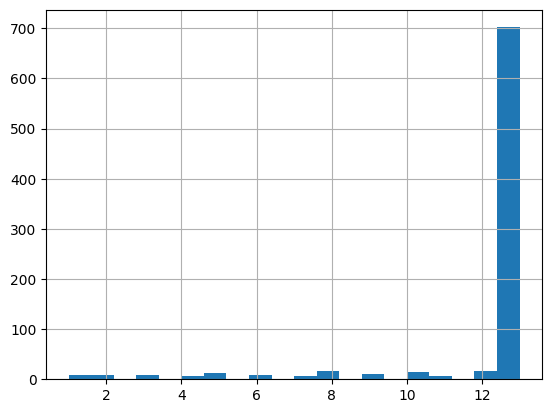

In [112]:
customer_history = df_sample.groupby("customer_ID").size()

customer_history.hist(bins=20)

In [113]:
df_sample["S_2"] = pd.to_datetime(df_sample["S_2"])

Observe one customer over time

In [115]:
customer_id = df_sample["customer_ID"].iloc[0]

customer_df = (
    df_sample[df_sample["customer_ID"] == customer_id]
    .sort_values("S_2")
)

customer_df[["customer_ID", "S_2"]].head(20)

,customer_ID,S_2
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-03-09
1,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-04-07
2,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-05-28
3,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-06-13
4,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-07-16
5,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-08-04
6,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-09-18
7,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-10-08
8,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-11-20
9,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-12-04


Look for behavioral movement

In [116]:
customer_df[["S_2", "B_1", "D_39", "R_1"]]

,S_2,B_1,D_39,R_1
0,2017-03-09,0.008724,0.001733,0.009228
1,2017-04-07,0.004923,0.005775,0.006151
2,2017-05-28,0.021655,0.091505,0.006815
3,2017-06-13,0.013683,0.002455,0.001373
4,2017-07-16,0.015193,0.002483,0.007605
5,2017-08-04,0.007863,0.001746,0.004220
6,2017-09-18,0.018859,0.002183,0.004509
7,2017-10-08,0.014324,0.003029,0.000263
8,2017-11-20,0.016888,0.009896,0.001789
9,2017-12-04,0.001930,0.001082,0.001772


Compare defaults vs non-defaults

In [117]:
df_sample.groupby("target")["B_1"].mean()

target
0    0.079193
1    0.263109
Name: B_1, dtype: float64

In [118]:
df_sample.groupby("target")["D_39"].mean()

target
0    0.126287
1    0.246710
Name: D_39, dtype: float64

In [119]:
df_sample.groupby("target")["R_1"].mean()

target
0    0.025936
1    0.214338
Name: R_1, dtype: float64

Variability Analysis

In [120]:
df_sample.groupby("target")["B_1"].std()

target
0    0.154011
1    0.287056
Name: B_1, dtype: float64

In [121]:
df_sample.groupby("target")["D_39"].std()

target
0    0.206177
1    0.404053
Name: D_39, dtype: float64

In [122]:
df_sample.groupby("target")["R_1"].std()

target
0    0.108204
1    0.359155
Name: R_1, dtype: float64

Visualize feature distribution

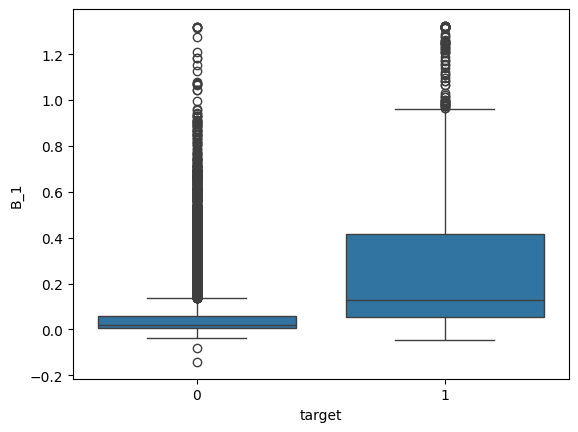

In [123]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="target", y="B_1", data=df_sample)

plt.show()

<Axes: xlabel='target', ylabel='B_1'>

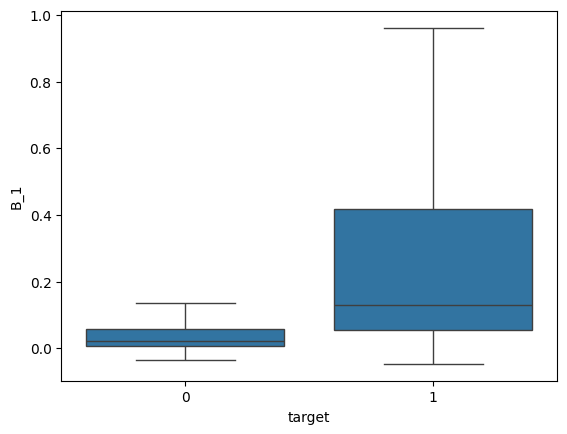

In [124]:
sns.boxplot(x="target", y="B_1", data=df_sample, showfliers=False)

<Axes: xlabel='target', ylabel='B_1'>

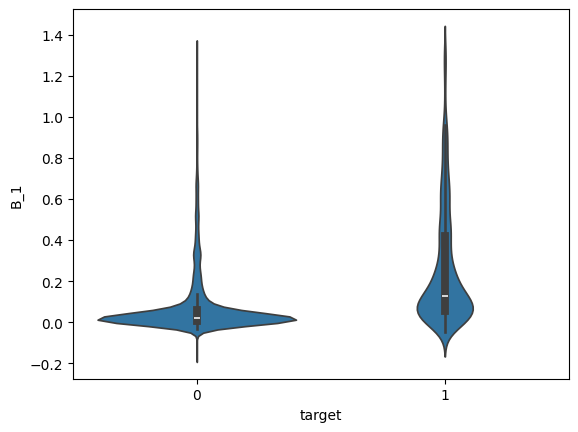

In [127]:
sns.violinplot(x="target", y="B_1", data=df_sample)

<Axes: xlabel='target', ylabel='D_39'>

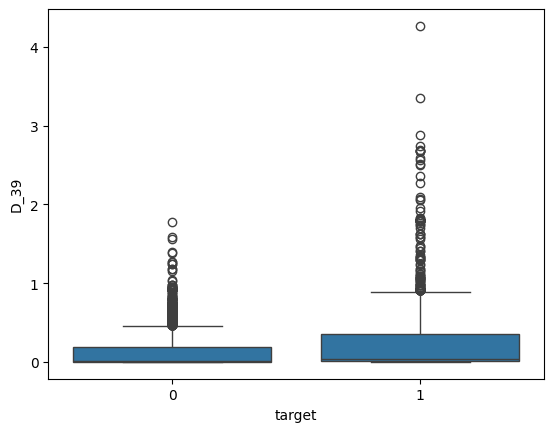

In [128]:
sns.boxplot(x="target", y="D_39", data=df_sample)

<Axes: xlabel='target', ylabel='R_1'>

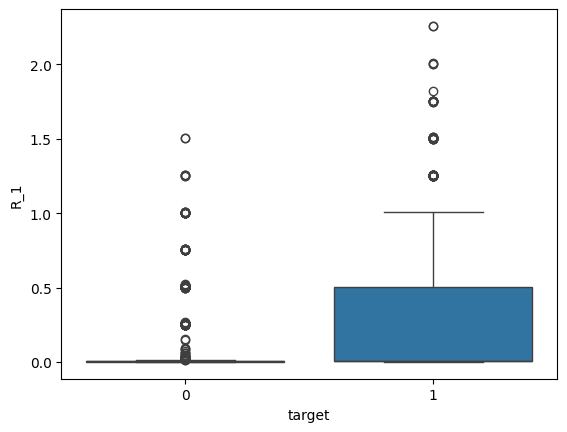

In [129]:
sns.boxplot(x="target", y="R_1", data=df_sample)

Pick small feature subset first

In [233]:
selected_features = [
    "B_1",
    "D_39",
    "R_1"
]

In [234]:
selected_features

['B_1', 'D_39', 'R_1']

Create Aggregation Table 

In [235]:
agg_df = df_sample.groupby("customer_ID")[selected_features].agg([
    "mean",
    "std",
    "min",
    "max",
    "last"
])

Flatten column names

In [236]:
agg_df

B_1            \
                                                        mean       std   
customer_ID                                                              
0000099d6bd597052cdcda90ffabf56573fe9d7c79be5fb...  0.012007  0.006547   
00000fd6641609c6ece5454664794f0340ad84dddce9a26...  0.025654  0.027756   
00001b22f846c82c51f6e3958ccd81970162bae8b007e80...  0.004386  0.002786   
000041bdba6ecadd89a52d11886e8eaaec9325906c97233...  0.059876  0.080531   
00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8ad...  0.005941  0.002475   
...                                                      ...       ...   
00774cde32a3a8894c5274e49092252b0d78cc49bffbb81...  0.465420  0.040780   
007756f6fbf1c36b946f3a1723cdcb4a755624c433488a1...  0.006772  0.002601   
00777a52c3c78548ce384dbc412025582291370ac2790c4...  1.245609  0.032849   
007793144e0eeef1e29a7aa93244815328beb0d46ccbe3d...  0.046328  0.006342   
0077b7efafef4cfa81e42538b87e39799e9928e47c6826e...  0.021667  0.009813   

                                                                        \
                                                         min       max   
customer_ID                                                              
0000099d6bd597052cdcda90ffabf56573fe9d7c79be5fb...  0.001930  0.021655   
00000fd6641609c6ece5454664794f0340ad84dddce9a26...  0.006711  0.109644   
00001b22f846c82c51f6e3958ccd81970162bae8b007e80...  0.001472  0.009997   
000041bdba6ecadd89a52d11886e8eaaec9325906c97233...  0.005910  0.279991   
00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8ad...  0.000776  0.009806   
...                                                      ...       ...   
00774cde32a3a8894c5274e49092252b0d78cc49bffbb81...  0.424204  0.552510   
007756f6fbf1c36b946f3a1723cdcb4a755624c433488a1...  0.002348  0.009898   
00777a52c3c78548ce384dbc412025582291370ac2790c4...  1.157685  1.290363   
007793144e0eeef1e29a7aa93244815328beb0d46ccbe3d...  0.034312  0.053203   
0077b7efafef4cfa81e42538b87e39799e9928e47c6826e...  0.013953  0.032713   

                                                                  D_39  \
                                                        last      mean   
customer_ID                                                              
0000099d6bd597052cdcda90ffabf56573fe9d7c79be5fb...  0.009382  0.010704   
00000fd6641609c6ece5454664794f0340ad84dddce9a26...  0.034684  0.215205   
00001b22f846c82c51f6e3958ccd81970162bae8b007e80...  0.004284  0.004181   
000041bdba6ecadd89a52d11886e8eaaec9325906c97233...  0.012564  0.048862   
00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8ad...  0.007679  0.004644   
...                                                      ...       ...   
00774cde32a3a8894c5274e49092252b0d78cc49bffbb81...  0.505187  0.496306   
007756f6fbf1c36b946f3a1723cdcb4a755624c433488a1...  0.007741  0.005185   
00777a52c3c78548ce384dbc412025582291370ac2790c4...  1.281433  0.333018   
007793144e0eeef1e29a7aa93244815328beb0d46ccbe3d...  0.048313  0.775386   
0077b7efafef4cfa81e42538b87e39799e9928e47c6826e...  0.032713  0.270594   

                                                                        \
                                                         std       min   
customer_ID                                                              
0000099d6bd597052cdcda90ffabf56573fe9d7c79be5fb...  0.024444  0.001082   
00000fd6641609c6ece5454664794f0340ad84dddce9a26...  0.199150  0.002224   
00001b22f846c82c51f6e3958ccd81970162bae8b007e80...  0.002758  0.000802   
000041bdba6ecadd89a52d11886e8eaaec9325906c97233...  0.088466  0.000660   
00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8ad...  0.002882  0.000030   
...                                                      ...       ...   
00774cde32a3a8894c5274e49092252b0d78cc49bffbb81...  0.096849  0.296945   
007756f6fbf1c36b946f3a1723cdcb4a755624c433488a1...  0.002348  0.001866   
00777a52c3c78548ce384dbc412025582291370ac2790c4...  0.517025  0.001022   
007793144e0eeef1e29a7aa93244815328beb0d46ccbe3d...  0.6125

In [237]:
agg_df.columns = [
    f"{col}_{stat}"
    for col, stat in agg_df.columns
]

In [238]:
agg_df

,B_1_mean,B_1_std,B_1_min,B_1_max,B_1_last,D_39_mean,D_39_std,D_39_min,D_39_max,D_39_last,R_1_mean,R_1_std,R_1_min,R_1_max,R_1_last
customer_ID,,,,,,,,,,,,,,,
0000099d6bd597052cdcda90ffabf56573fe9d7c79be5fbac11a8ed792feb62a,0.012007,0.006547,0.001930,0.021655,0.009382,0.010704,0.024444,0.001082,0.091505,0.009119,0.004509,0.003081,0.000263,0.009228,0.006104
00000fd6641609c6ece5454664794f0340ad84dddce9a267a310b5ae68e9d8e5,0.025654,0.027756,0.006711,0.109644,0.034684,0.215205,0.199150,0.002224,0.567403,0.178126,0.006246,0.002129,0.001023,0.008996,0.006911
00001b22f846c82c51f6e3958ccd81970162bae8b007e80662ef27519fcc18c1,0.004386,0.002786,0.001472,0.009997,0.004284,0.004181,0.002758,0.000802,0.009704,0.009704,0.006621,0.001919,0.003540,0.009443,0.006450
000041bdba6ecadd89a52d11886e8eaaec9325906c9723355abb5ca523658edc,0.059876,0.080531,0.005910,0.279991,0.012564,0.048862,0.088466,0.000660,0.268476,0.001083,0.005665,0.003473,0.000199,0.009915,0.007829
00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8ad51ca8b8c4a24cefed,0.005941,0.002475,0.000776,0.009806,0.007679,0.004644,0.002882,0.000030,0.008680,0.005573,0.004180,0.002581,0.000336,0.009076,0.001247
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
00774cde32a3a8894c5274e49092252b0d78cc49bffbb81ea74a7e109e1b4ad5,0.465420,0.040780,0.424204,0.552510,0.505187,0.496306,0.096849,0.296945,0.708103,0.296945,0.003793,0.002235,0.000257,0.007653,0.007253
007756f6fbf1c36b946f3a1723cdcb4a755624c433488a1198a8dbed89acbfcf,0.006772,0.002601,0.002348,0.009898,0.007741,0.005185,0.002348,0.001866,0.009965,0.008057,0.004217,0.003399,0.000589,0.009294,0.000645
00777a52c3c78548ce384dbc412025582291370ac2790c44c0ee9c93b994c212,1.245609,0.032849,1.157685,1.290363,1.281433,0.333018,0.517025,0.001022,1.795979,1.795979,0.159715,0.239895,0.002363,0.509277,0.502404


Reset Index

In [239]:
agg_df = agg_df.reset_index()

In [240]:
agg_df

,customer_ID,B_1_mean,B_1_std,B_1_min,B_1_max,B_1_last,D_39_mean,D_39_std,D_39_min,D_39_max,D_39_last,R_1_mean,R_1_std,R_1_min,R_1_max,R_1_last
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,0.012007,0.006547,0.001930,0.021655,0.009382,0.010704,0.024444,0.001082,0.091505,0.009119,0.004509,0.003081,0.000263,0.009228,0.006104
1,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,0.025654,0.027756,0.006711,0.109644,0.034684,0.215205,0.199150,0.002224,0.567403,0.178126,0.006246,0.002129,0.001023,0.008996,0.006911
2,00001b22f846c82c51f6e3958ccd81970162bae8b007e8...,0.004386,0.002786,0.001472,0.009997,0.004284,0.004181,0.002758,0.000802,0.009704,0.009704,0.006621,0.001919,0.003540,0.009443,0.006450
3,000041bdba6ecadd89a52d11886e8eaaec9325906c9723...,0.059876,0.080531,0.005910,0.279991,0.012564,0.048862,0.088466,0.000660,0.268476,0.001083,0.005665,0.003473,0.000199,0.009915,0.007829
4,00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8a...,0.005941,0.002475,0.000776,0.009806,0.007679,0.004644,0.002882,0.000030,0.008680,0.005573,0.004180,0.002581,0.000336,0.009076,0.001247
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
821,00774cde32a3a8894c5274e49092252b0d78cc49bffbb8...,0.465420,0.040780,0.424204,0.552510,0.505187,0.496306,0.096849,0.296945,0.708103,0.296945,0.003793,0.002235,0.000257,0.007653,0.007253
822,007756f6fbf1c36b946f3a1723cdcb4a755624c433488a...,0.006772,0.002601,0.002348,0.009898,0.007741,0.005185,0.002348,0.001866,0.009965,0.008057,0.004217,0.003399,0.000589,0.009294,0.000645
823,00777a52c3c78548ce384dbc412025582291370ac2790c...,1.245609,0.032849,1.157685,1.290363,1.281433,0.333018,0.517025,0.001022,1.795979,1.795979,0.159715,0.239895,0.002363,0.509277,0.502404
824,007793144e0eeef1e29a7aa93244815328beb0d46ccbe3...,0.046328,0.006342,0.034312,0.053203,0.048313,0.775386,0.612509,0.006545,2.065567,2.065567,0.081417,0.187606,0.000280,0.505331,0.006775


Merge Target

In [241]:
agg_df = agg_df.merge(df_labels, on="customer_ID", how="left")

Inspect Result 

In [242]:
agg_df

,customer_ID,B_1_mean,B_1_std,B_1_min,B_1_max,B_1_last,D_39_mean,D_39_std,D_39_min,D_39_max,D_39_last,R_1_mean,R_1_std,R_1_min,R_1_max,R_1_last,target
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,0.012007,0.006547,0.001930,0.021655,0.009382,0.010704,0.024444,0.001082,0.091505,0.009119,0.004509,0.003081,0.000263,0.009228,0.006104,0
1,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,0.025654,0.027756,0.006711,0.109644,0.034684,0.215205,0.199150,0.002224,0.567403,0.178126,0.006246,0.002129,0.001023,0.008996,0.006911,0
2,00001b22f846c82c51f6e3958ccd81970162bae8b007e8...,0.004386,0.002786,0.001472,0.009997,0.004284,0.004181,0.002758,0.000802,0.009704,0.009704,0.006621,0.001919,0.003540,0.009443,0.006450,0
3,000041bdba6ecadd89a52d11886e8eaaec9325906c9723...,0.059876,0.080531,0.005910,0.279991,0.012564,0.048862,0.088466,0.000660,0.268476,0.001083,0.005665,0.003473,0.000199,0.009915,0.007829,0
4,00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8a...,0.005941,0.002475,0.000776,0.009806,0.007679,0.004644,0.002882,0.000030,0.008680,0.005573,0.004180,0.002581,0.000336,0.009076,0.001247,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
821,00774cde32a3a8894c5274e49092252b0d78cc49bffbb8...,0.465420,0.040780,0.424204,0.552510,0.505187,0.496306,0.096849,0.296945,0.708103,0.296945,0.003793,0.002235,0.000257,0.007653,0.007253,1
822,007756f6fbf1c36b946f3a1723cdcb4a755624c433488a...,0.006772,0.002601,0.002348,0.009898,0.007741,0.005185,0.002348,0.001866,0.009965,0.008057,0.004217,0.003399,0.000589,0.009294,0.000645,0
823,00777a52c3c78548ce384dbc412025582291370ac2790c...,1.245609,0.032849,1.157685,1.290363,1.281433,0.333018,0.517025,0.001022,1.795979,1.795979,0.159715,0.239895,0.002363,0.509277,0.502404,1
824,007793144e0eeef1e29a7aa93244815328beb0d46ccbe3...,0.046328,0.006342,0.034312,0.053203,0.048313,0.775386,0.612509,0.006545,2.065567,2.065567,0.081417,0.187606,0.000280,0.505331,0.006775,1


In [243]:
agg_df.shape

(826, 17)

Checking missingnes in Engineered Features 

In [244]:
agg_df.isnull().mean().sort_values(ascending=False)

B_1_std        0.010896
R_1_std        0.010896
D_39_std       0.010896
customer_ID    0.000000
D_39_last      0.000000
R_1_last       0.000000
R_1_max        0.000000
R_1_min        0.000000
R_1_mean       0.000000
D_39_min       0.000000
D_39_max       0.000000
B_1_mean       0.000000
D_39_mean      0.000000
B_1_last       0.000000
B_1_max        0.000000
B_1_min        0.000000
target         0.000000
dtype: float64

Base Modelling
Prepare Feature Matrix

In [245]:
X = agg_df.drop(columns=["customer_ID", "target"])
y = agg_df["target"]


Train Test Split

In [246]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [247]:
X_train.shape

(660, 15)

In [248]:
X_test.shape

(166, 15)

In [249]:
y_train.head()

115    0
714    1
267    1
659    0
544    0
Name: target, dtype: int64

In [250]:
y_test.shape

(166,)

In [251]:
history_length = df_sample.groupby("customer_ID").size().reset_index(name="history_length")

In [252]:
history_length

,customer_ID,history_length
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,13
1,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,13
2,00001b22f846c82c51f6e3958ccd81970162bae8b007e8...,13
3,000041bdba6ecadd89a52d11886e8eaaec9325906c9723...,13
4,00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8a...,13
...,...,...
821,00774cde32a3a8894c5274e49092252b0d78cc49bffbb8...,13
822,007756f6fbf1c36b946f3a1723cdcb4a755624c433488a...,13
823,00777a52c3c78548ce384dbc412025582291370ac2790c...,13
824,007793144e0eeef1e29a7aa93244815328beb0d46ccbe3...,13


In [253]:
agg_debug = agg_df.merge(history_length, on="customer_ID", how="left")

In [254]:
agg_debug

,customer_ID,B_1_mean,B_1_std,B_1_min,B_1_max,B_1_last,D_39_mean,D_39_std,D_39_min,D_39_max,D_39_last,R_1_mean,R_1_std,R_1_min,R_1_max,R_1_last,target,history_length
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,0.012007,0.006547,0.001930,0.021655,0.009382,0.010704,0.024444,0.001082,0.091505,0.009119,0.004509,0.003081,0.000263,0.009228,0.006104,0,13
1,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,0.025654,0.027756,0.006711,0.109644,0.034684,0.215205,0.199150,0.002224,0.567403,0.178126,0.006246,0.002129,0.001023,0.008996,0.006911,0,13
2,00001b22f846c82c51f6e3958ccd81970162bae8b007e8...,0.004386,0.002786,0.001472,0.009997,0.004284,0.004181,0.002758,0.000802,0.009704,0.009704,0.006621,0.001919,0.003540,0.009443,0.006450,0,13
3,000041bdba6ecadd89a52d11886e8eaaec9325906c9723...,0.059876,0.080531,0.005910,0.279991,0.012564,0.048862,0.088466,0.000660,0.268476,0.001083,0.005665,0.003473,0.000199,0.009915,0.007829,0,13
4,00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8a...,0.005941,0.002475,0.000776,0.009806,0.007679,0.004644,0.002882,0.000030,0.008680,0.005573,0.004180,0.002581,0.000336,0.009076,0.001247,0,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
821,00774cde32a3a8894c5274e49092252b0d78cc49bffbb8...,0.465420,0.040780,0.424204,0.552510,0.505187,0.496306,0.096849,0.296945,0.708103,0.296945,0.003793,0.002235,0.000257,0.007653,0.007253,1,13
822,007756f6fbf1c36b946f3a1723cdcb4a755624c433488a...,0.006772,0.002601,0.002348,0.009898,0.007741,0.005185,0.002348,0.001866,0.009965,0.008057,0.004217,0.003399,0.000589,0.009294,0.000645,0,13
823,00777a52c3c78548ce384dbc412025582291370ac2790c...,1.245609,0.032849,1.157685,1.290363,1.281433,0.333018,0.517025,0.001022,1.795979,1.795979,0.159715,0.239895,0.002363,0.509277,0.502404,1,13
824,007793144e0eeef1e29a7aa93244815328beb0d46ccbe3...,0.046328,0.006342,0.034312,0.053203,0.048313,0.775386,0.612509,0.006545,2.065567,2.065567,0.081417,0.187606,0.000280,0.505331,0.006775,1,13


In [255]:
agg_debug[agg_debug["B_1_std"].isnull()][["customer_ID", "history_length", "B_1_mean", "B_1_std"]].head(20)

,customer_ID,history_length,B_1_mean,B_1_std
63,0009bd8871169b8d76a445e1f52079a6edc0b6f0bf021d...,1,0.003712,NaN
97,000eee12732c9c7b790870c556bc33339d6d17725cbeb4...,1,0.079262,NaN
145,0015d621bacbfd59cc1479aea405645ecb480f6ee779e0...,1,0.048989,NaN
149,00163cf7b8cc9cb2781ac05331d83c3ae7720f4860ee8a...,1,1.317920,NaN
497,004bf15cf65c01b2173e53c5284933d41650e69d977ebd...,1,0.046566,NaN
590,005750fedff03417405a5ba8485c28bafb87c4149668b9...,1,0.017442,NaN
610,005a7f765eee4afa0455c5a3662ab8bc352b49cabac0ed...,1,1.317488,NaN
697,0066a59c8b96adec9e847a64d83d481f8b67eb6b96eac0...,1,0.089652,NaN
809,007640e6d0fb8423be50a40c337108db80471dae973fc8...,1,0.031857,NaN


In [256]:
agg_debug

,customer_ID,B_1_mean,B_1_std,B_1_min,B_1_max,B_1_last,D_39_mean,D_39_std,D_39_min,D_39_max,D_39_last,R_1_mean,R_1_std,R_1_min,R_1_max,R_1_last,target,history_length
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,0.012007,0.006547,0.001930,0.021655,0.009382,0.010704,0.024444,0.001082,0.091505,0.009119,0.004509,0.003081,0.000263,0.009228,0.006104,0,13
1,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,0.025654,0.027756,0.006711,0.109644,0.034684,0.215205,0.199150,0.002224,0.567403,0.178126,0.006246,0.002129,0.001023,0.008996,0.006911,0,13
2,00001b22f846c82c51f6e3958ccd81970162bae8b007e8...,0.004386,0.002786,0.001472,0.009997,0.004284,0.004181,0.002758,0.000802,0.009704,0.009704,0.006621,0.001919,0.003540,0.009443,0.006450,0,13
3,000041bdba6ecadd89a52d11886e8eaaec9325906c9723...,0.059876,0.080531,0.005910,0.279991,0.012564,0.048862,0.088466,0.000660,0.268476,0.001083,0.005665,0.003473,0.000199,0.009915,0.007829,0,13
4,00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8a...,0.005941,0.002475,0.000776,0.009806,0.007679,0.004644,0.002882,0.000030,0.008680,0.005573,0.004180,0.002581,0.000336,0.009076,0.001247,0,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
821,00774cde32a3a8894c5274e49092252b0d78cc49bffbb8...,0.465420,0.040780,0.424204,0.552510,0.505187,0.496306,0.096849,0.296945,0.708103,0.296945,0.003793,0.002235,0.000257,0.007653,0.007253,1,13
822,007756f6fbf1c36b946f3a1723cdcb4a755624c433488a...,0.006772,0.002601,0.002348,0.009898,0.007741,0.005185,0.002348,0.001866,0.009965,0.008057,0.004217,0.003399,0.000589,0.009294,0.000645,0,13
823,00777a52c3c78548ce384dbc412025582291370ac2790c...,1.245609,0.032849,1.157685,1.290363,1.281433,0.333018,0.517025,0.001022,1.795979,1.795979,0.159715,0.239895,0.002363,0.509277,0.502404,1,13
824,007793144e0eeef1e29a7aa93244815328beb0d46ccbe3...,0.046328,0.006342,0.034312,0.053203,0.048313,0.775386,0.612509,0.006545,2.065567,2.065567,0.081417,0.187606,0.000280,0.505331,0.006775,1,13


Let’s test whether missingness is predictive

In [257]:
agg_debug["std_missing"] = agg_debug["B_1_std"].isnull().astype(int)

agg_debug.groupby("std_missing")["target"].mean()

std_missing
0    0.266830
1    0.444444
Name: target, dtype: float64

Also add history length

In [258]:
agg_debug.groupby("history_length")["target"].mean().sort_index()

history_length
1     0.444444
2     0.375000
3     0.333333
4     0.714286
5     0.615385
6     0.125000
7     0.666667
8     0.312500
9     0.600000
10    0.428571
11    0.571429
12    0.411765
13    0.236467
Name: target, dtype: float64

In [259]:
agg_debug

,customer_ID,B_1_mean,B_1_std,B_1_min,B_1_max,B_1_last,D_39_mean,D_39_std,D_39_min,D_39_max,D_39_last,R_1_mean,R_1_std,R_1_min,R_1_max,R_1_last,target,history_length,std_missing
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,0.012007,0.006547,0.001930,0.021655,0.009382,0.010704,0.024444,0.001082,0.091505,0.009119,0.004509,0.003081,0.000263,0.009228,0.006104,0,13,0
1,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,0.025654,0.027756,0.006711,0.109644,0.034684,0.215205,0.199150,0.002224,0.567403,0.178126,0.006246,0.002129,0.001023,0.008996,0.006911,0,13,0
2,00001b22f846c82c51f6e3958ccd81970162bae8b007e8...,0.004386,0.002786,0.001472,0.009997,0.004284,0.004181,0.002758,0.000802,0.009704,0.009704,0.006621,0.001919,0.003540,0.009443,0.006450,0,13,0
3,000041bdba6ecadd89a52d11886e8eaaec9325906c9723...,0.059876,0.080531,0.005910,0.279991,0.012564,0.048862,0.088466,0.000660,0.268476,0.001083,0.005665,0.003473,0.000199,0.009915,0.007829,0,13,0
4,00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8a...,0.005941,0.002475,0.000776,0.009806,0.007679,0.004644,0.002882,0.000030,0.008680,0.005573,0.004180,0.002581,0.000336,0.009076,0.001247,0,13,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
821,00774cde32a3a8894c5274e49092252b0d78cc49bffbb8...,0.465420,0.040780,0.424204,0.552510,0.505187,0.496306,0.096849,0.296945,0.708103,0.296945,0.003793,0.002235,0.000257,0.007653,0.007253,1,13,0
822,007756f6fbf1c36b946f3a1723cdcb4a755624c433488a...,0.006772,0.002601,0.002348,0.009898,0.007741,0.005185,0.002348,0.001866,0.009965,0.008057,0.004217,0.003399,0.000589,0.009294,0.000645,0,13,0
823,00777a52c3c78548ce384dbc412025582291370ac2790c...,1.245609,0.032849,1.157685,1.290363,1.281433,0.333018,0.517025,0.001022,1.795979,1.795979,0.159715,0.239895,0.002363,0.509277,0.502404,1,13,0
824,007793144e0eeef1e29a7aa93244815328beb0d46ccbe3...,0.046328,0.006342,0.034312,0.053203,0.048313,0.775386,0.612509,0.006545,2.065567,2.065567,0.081417,0.187606,0.000280,0.505331,0.006775,1,13,0


In [260]:
history_length = df_sample.groupby("customer_ID").size().reset_index(name="history_length")

agg_debug = agg_df.merge(history_length, on="customer_ID", how="left")

agg_debug["std_missing"] = agg_debug["B_1_std"].isnull().astype(int)

print("Default rate by std missingness:")
print(agg_debug.groupby("std_missing")["target"].mean())

print("\nDefault rate by history length:")
print(agg_debug.groupby("history_length")["target"].mean().sort_index())

Default rate by std missingness:
std_missing
0    0.266830
1    0.444444
Name: target, dtype: float64

Default rate by history length:
history_length
1     0.444444
2     0.375000
3     0.333333
4     0.714286
5     0.615385
6     0.125000
7     0.666667
8     0.312500
9     0.600000
10    0.428571
11    0.571429
12    0.411765
13    0.236467
Name: target, dtype: float64


Add history length Feature

In [261]:
agg_df = agg_df.merge(
    history_length,
    on="customer_ID",
    how="left"
)

In [262]:
agg_df

,customer_ID,B_1_mean,B_1_std,B_1_min,B_1_max,B_1_last,D_39_mean,D_39_std,D_39_min,D_39_max,D_39_last,R_1_mean,R_1_std,R_1_min,R_1_max,R_1_last,target,history_length
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,0.012007,0.006547,0.001930,0.021655,0.009382,0.010704,0.024444,0.001082,0.091505,0.009119,0.004509,0.003081,0.000263,0.009228,0.006104,0,13
1,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,0.025654,0.027756,0.006711,0.109644,0.034684,0.215205,0.199150,0.002224,0.567403,0.178126,0.006246,0.002129,0.001023,0.008996,0.006911,0,13
2,00001b22f846c82c51f6e3958ccd81970162bae8b007e8...,0.004386,0.002786,0.001472,0.009997,0.004284,0.004181,0.002758,0.000802,0.009704,0.009704,0.006621,0.001919,0.003540,0.009443,0.006450,0,13
3,000041bdba6ecadd89a52d11886e8eaaec9325906c9723...,0.059876,0.080531,0.005910,0.279991,0.012564,0.048862,0.088466,0.000660,0.268476,0.001083,0.005665,0.003473,0.000199,0.009915,0.007829,0,13
4,00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8a...,0.005941,0.002475,0.000776,0.009806,0.007679,0.004644,0.002882,0.000030,0.008680,0.005573,0.004180,0.002581,0.000336,0.009076,0.001247,0,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
821,00774cde32a3a8894c5274e49092252b0d78cc49bffbb8...,0.465420,0.040780,0.424204,0.552510,0.505187,0.496306,0.096849,0.296945,0.708103,0.296945,0.003793,0.002235,0.000257,0.007653,0.007253,1,13
822,007756f6fbf1c36b946f3a1723cdcb4a755624c433488a...,0.006772,0.002601,0.002348,0.009898,0.007741,0.005185,0.002348,0.001866,0.009965,0.008057,0.004217,0.003399,0.000589,0.009294,0.000645,0,13
823,00777a52c3c78548ce384dbc412025582291370ac2790c...,1.245609,0.032849,1.157685,1.290363,1.281433,0.333018,0.517025,0.001022,1.795979,1.795979,0.159715,0.239895,0.002363,0.509277,0.502404,1,13
824,007793144e0eeef1e29a7aa93244815328beb0d46ccbe3...,0.046328,0.006342,0.034312,0.053203,0.048313,0.775386,0.612509,0.006545,2.065567,2.065567,0.081417,0.187606,0.000280,0.505331,0.006775,1,13


Rebuild X and y

In [263]:
X = agg_df.drop(columns=["customer_ID", "target"])
y = agg_df["target"]

In [264]:
X

,B_1_mean,B_1_std,B_1_min,B_1_max,B_1_last,D_39_mean,D_39_std,D_39_min,D_39_max,D_39_last,R_1_mean,R_1_std,R_1_min,R_1_max,R_1_last,history_length
0,0.012007,0.006547,0.001930,0.021655,0.009382,0.010704,0.024444,0.001082,0.091505,0.009119,0.004509,0.003081,0.000263,0.009228,0.006104,13
1,0.025654,0.027756,0.006711,0.109644,0.034684,0.215205,0.199150,0.002224,0.567403,0.178126,0.006246,0.002129,0.001023,0.008996,0.006911,13
2,0.004386,0.002786,0.001472,0.009997,0.004284,0.004181,0.002758,0.000802,0.009704,0.009704,0.006621,0.001919,0.003540,0.009443,0.006450,13
3,0.059876,0.080531,0.005910,0.279991,0.012564,0.048862,0.088466,0.000660,0.268476,0.001083,0.005665,0.003473,0.000199,0.009915,0.007829,13
4,0.005941,0.002475,0.000776,0.009806,0.007679,0.004644,0.002882,0.000030,0.008680,0.005573,0.004180,0.002581,0.000336,0.009076,0.001247,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
821,0.465420,0.040780,0.424204,0.552510,0.505187,0.496306,0.096849,0.296945,0.708103,0.296945,0.003793,0.002235,0.000257,0.007653,0.007253,13
822,0.006772,0.002601,0.002348,0.009898,0.007741,0.005185,0.002348,0.001866,0.009965,0.008057,0.004217,0.003399,0.000589,0.009294,0.000645,13
823,1.245609,0.032849,1.157685,1.290363,1.281433,0.333018,0.517025,0.001022,1.795979,1.795979,0.159715,0.239895,0.002363,0.509277,0.502404,13
824,0.046328,0.006342,0.034312,0.053203,0.048313,0.775386,0.612509,0.006545,2.065567,2.065567,0.081417,0.187606,0.000280,0.505331,0.006775,13


In [265]:
y

0      0
1      0
2      0
3      0
4      0
      ..
821    1
822    0
823    1
824    1
825    0
Name: target, Length: 826, dtype: int64

Train-Test Split again

In [266]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

Imputation 

In [267]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

First baseline model


In [279]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_imputed, y_train)

LogisticRegression(max_iter=1000)

Predictions

In [280]:
y_pred = model.predict(X_test_imputed)

y_prob = model.predict_proba(X_test_imputed)[:, 1]

Evaluate properly 

In [281]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print(classification_report(y_test, y_pred))

Accuracy: 0.7891566265060241
ROC-AUC: 0.8372819100091827
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       121
           1       0.62      0.56      0.59        45

    accuracy                           0.79       166
   macro avg       0.73      0.72      0.72       166
weighted avg       0.78      0.79      0.79       166



Create Deterioration Features

In [303]:
agg_df["B_1_deterioration"] = agg_df["B_1_last"] - agg_df["B_1_mean"]

agg_df["D_39_deterioration"] = agg_df["D_39_last"] - agg_df["D_39_mean"]

agg_df["R_1_deterioration"] = agg_df["R_1_last"] - agg_df["R_1_mean"]

ReBuild X and y

In [304]:
X = agg_df.drop(columns=["customer_ID", "target"])

y = agg_df["target"]

Train/ Test Split again

In [305]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

Imputation again

In [306]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)

X_test_imputed = imputer.transform(X_test)

In [325]:
X_train_imputed

array([[ 0.04594103,  0.0778978 ,  0.00091494, ...,  0.19191576,
         0.64486503, -0.00505947],
       [ 0.37526267,  0.18788366,  0.08950302, ...,  0.30420142,
        -0.12950653, -0.00267853],
       [ 0.04925783,  0.03549932,  0.01337287, ..., -0.02116886,
         0.32140483,  0.20133676],
       ...,
       [ 0.0344333 ,  0.01270231,  0.01765187, ...,  0.01423546,
        -0.21214342, -0.08041206],
       [ 0.0254669 ,  0.00623449,  0.01200058, ...,  0.00747864,
         0.12041   ,  0.00122115],
       [ 0.02831132,  0.01459607,  0.00883666, ...,  0.00511417,
        -0.12998342, -0.00131983]])

Train Logistic Regression Again

In [308]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_imputed, y_train)

LogisticRegression(max_iter=1000)

Predictions

In [309]:
y_pred = model.predict(X_test_imputed)

y_prob = model.predict_proba(X_test_imputed)[:, 1]

Evaluate Again

In [310]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print(classification_report(y_test, y_pred))

Accuracy: 0.7891566265060241
ROC-AUC: 0.8352617079889807
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       121
           1       0.62      0.56      0.59        45

    accuracy                           0.79       166
   macro avg       0.73      0.72      0.72       166
weighted avg       0.78      0.79      0.79       166



Behaviour driver analysis->Create Coefficient Table

In [311]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0]
})

feature_importance = feature_importance.sort_values(
    by="coefficient",
    ascending=False
)

print(feature_importance)

               feature  coefficient
13             R_1_max     2.282540
4             B_1_last     1.993161
8             D_39_max     1.928223
0             B_1_mean     1.392811
11             R_1_std     1.366130
16   B_1_deterioration     0.600350
10            R_1_mean     0.532195
17  D_39_deterioration     0.482192
14            R_1_last     0.447359
6             D_39_std     0.248616
2              B_1_min     0.198282
3              B_1_max     0.158029
1              B_1_std     0.137313
7             D_39_min     0.084916
18   R_1_deterioration    -0.084836
9            D_39_last    -0.093928
15      history_length    -0.169485
12             R_1_min    -0.491123
5            D_39_mean    -0.576120


Import Scaler

In [317]:
from sklearn.preprocessing import StandardScaler

Scale Features

In [318]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)

X_test_scaled = scaler.transform(X_test_imputed)

In [324]:
X_train_imputed

array([[ 0.04594103,  0.0778978 ,  0.00091494, ...,  0.19191576,
         0.64486503, -0.00505947],
       [ 0.37526267,  0.18788366,  0.08950302, ...,  0.30420142,
        -0.12950653, -0.00267853],
       [ 0.04925783,  0.03549932,  0.01337287, ..., -0.02116886,
         0.32140483,  0.20133676],
       ...,
       [ 0.0344333 ,  0.01270231,  0.01765187, ...,  0.01423546,
        -0.21214342, -0.08041206],
       [ 0.0254669 ,  0.00623449,  0.01200058, ...,  0.00747864,
         0.12041   ,  0.00122115],
       [ 0.02831132,  0.01459607,  0.00883666, ...,  0.00511417,
        -0.12998342, -0.00131983]])

Train Logistic Regression Again

In [319]:
model_scaled = LogisticRegression(max_iter=1000)

model_scaled.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

Predictions

In [320]:
y_pred_scaled = model_scaled.predict(X_test_scaled)

y_prob_scaled = model_scaled.predict_proba(X_test_scaled)[:, 1]

Evaluate Again

In [326]:
print("Accuracy:", accuracy_score(y_test, y_pred_scaled))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_scaled))

print(classification_report(y_test, y_pred_scaled))

Accuracy: 0.8072289156626506
ROC-AUC: 0.8323232323232324
              precision    recall  f1-score   support

           0       0.86      0.88      0.87       121
           1       0.66      0.60      0.63        45

    accuracy                           0.81       166
   macro avg       0.76      0.74      0.75       166
weighted avg       0.80      0.81      0.80       166



Coefficient Table Again

In [327]:
feature_importance_scaled = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model_scaled.coef_[0]
})

feature_importance_scaled = feature_importance_scaled.sort_values(
    by="coefficient",
    ascending=False
)

print(feature_importance_scaled)

               feature  coefficient
0             B_1_mean     1.418352
8             D_39_max     1.286014
4             B_1_last     1.172296
11             R_1_std     0.955784
13             R_1_max     0.400838
1              B_1_std     0.237451
17  D_39_deterioration     0.182702
7             D_39_min     0.138562
10            R_1_mean     0.085435
14            R_1_last     0.062064
6             D_39_std     0.044648
18   R_1_deterioration     0.027017
9            D_39_last    -0.039263
12             R_1_min    -0.086256
16   B_1_deterioration    -0.112529
15      history_length    -0.439154
5            D_39_mean    -0.452407
2              B_1_min    -0.619197
3              B_1_max    -1.245320


NEXT STEP → Confusion Matrix

In [328]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_scaled)

print(cm)

[[107  14]
 [ 18  27]]


NEXT STEP → Lower Threshold

In [333]:
threshold = 0.35

y_pred_custom = (y_prob_scaled >= threshold).astype(int)

Evaluate Again

In [334]:
print(classification_report(y_test, y_pred_custom))

print(confusion_matrix(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.88      0.86      0.87       121
           1       0.65      0.69      0.67        45

    accuracy                           0.81       166
   macro avg       0.76      0.77      0.77       166
weighted avg       0.82      0.81      0.82       166

[[104  17]
 [ 14  31]]


NEXT BEST STEP

Now we should visualize:

Precision-Recall tradeoff

Because ROC-AUC alone is not enough for imbalanced risk systems.

This is where you start understanding:

threshold behavior,
operating regions,
business calibration

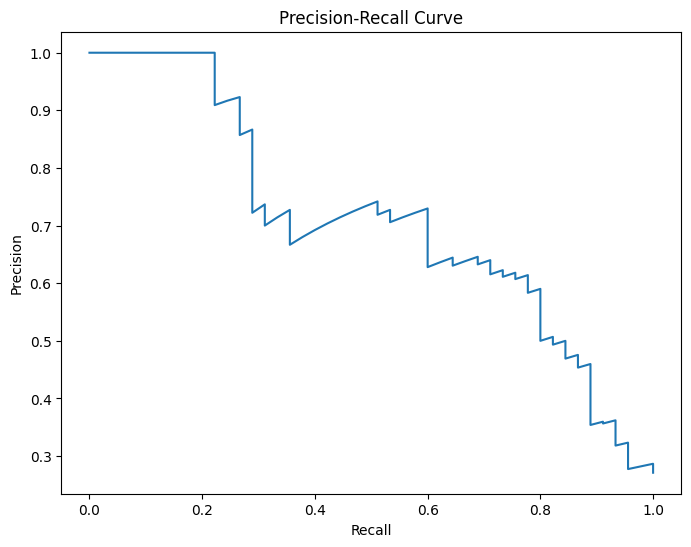

In [335]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob_scaled
)

plt.figure(figsize=(8,6))

plt.plot(recall, precision)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.show()

Next Step

In [420]:
# risk_df = pd.DataFrame({
#     "actual_target": y_test.values,
#     "predicted_probability": y_prob_scaled
# })


risk_df = pd.DataFrame({
    "actual_target": y_test,
    "predicted_probability": y_prob_scaled
}, index=y_test.index)

In [421]:
risk_df

,actual_target,predicted_probability
688,0,0.044581
756,0,0.016927
4,0,0.016837
368,1,0.415756
261,0,0.093251
...,...,...
709,1,0.067309
645,0,0.107081
82,0,0.244779
497,1,0.160685


Create Risk Bands 

In [422]:
risk_df["risk_band"] = pd.cut(
    risk_df["predicted_probability"],
    bins=[0, 0.2, 0.5, 0.8, 1.0],
    labels=["Low", "Medium", "High", "Critical"]
)

See Distribution

In [423]:
print(risk_df["risk_band"].value_counts())

risk_band
Low         107
Critical     24
Medium       18
High         17
Name: count, dtype: int64


Default Rate per band 

In [424]:
print(
    risk_df.groupby("risk_band")["actual_target"].mean()
)

risk_band
Low         0.093458
Medium      0.444444
High        0.647059
Critical    0.666667
Name: actual_target, dtype: float64


/var/folders/_x/zslfq00j131045lvgjlh0m540000gn/T/ipykernel_19314/1186028100.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_df.groupby("risk_band")["actual_target"].mean()


NEXT BEST STEP

Now we should identify:

highest-risk customers

This becomes:

local explainability
case-level analysis
analyst workflow simulation

Very important.

In [425]:
risk_df_sorted = risk_df.sort_values(
    by="predicted_probability",
    ascending=False
)

print(risk_df_sorted.head(20))

     actual_target  predicted_probability risk_band
610              1               0.997841  Critical
525              1               0.997430  Critical
337              1               0.997327  Critical
666              1               0.996708  Critical
174              1               0.996531  Critical
352              1               0.987330  Critical
310              1               0.980525  Critical
520              1               0.979590  Critical
539              1               0.971044  Critical
12               1               0.957099  Critical
332              0               0.954443  Critical
186              1               0.944115  Critical
300              1               0.940756  Critical
512              0               0.922762  Critical
21               1               0.922483  Critical
660              0               0.889789  Critical
280              0               0.886254  Critical
205              0               0.878334  Critical
641         

Next Step

Pick ONE:

true positive high-risk customer,
false positive high-risk customer

In [407]:
X_test_original = pd.DataFrame(
    X_test_imputed,
    columns=X.columns,
    index=X_test.index
)

In [430]:
X_test_original

,B_1_mean,B_1_std,B_1_min,B_1_max,B_1_last,D_39_mean,D_39_std,D_39_min,D_39_max,D_39_last,R_1_mean,R_1_std,R_1_min,R_1_max,R_1_last,history_length,B_1_deterioration,D_39_deterioration,R_1_deterioration
688,0.040515,0.017799,0.006894,0.062298,0.040340,0.075484,0.114585,0.001415,0.326869,0.005600,0.005158,0.003203,0.000741,0.009512,0.000846,12.0,-0.000175,-0.069885,-0.004312
756,0.005987,0.002398,0.001186,0.009202,0.006358,0.005546,0.003085,0.000812,0.009948,0.009653,0.003924,0.003060,0.000808,0.009440,0.006639,13.0,0.000371,0.004107,0.002716
4,0.005941,0.002475,0.000776,0.009806,0.007679,0.004644,0.002882,0.000030,0.008680,0.005573,0.004180,0.002581,0.000336,0.009076,0.001247,13.0,0.001739,0.000929,-0.002932
368,0.139233,0.088557,0.058980,0.288172,0.288172,0.189052,0.183474,0.000773,0.448370,0.210784,0.063567,0.207126,0.000257,0.752875,0.005524,13.0,0.148940,0.021732,-0.058043
261,0.143048,0.060911,0.079696,0.241361,0.222262,0.258931,0.258937,0.000499,0.682349,0.005906,0.005826,0.003251,0.000480,0.009163,0.008748,13.0,0.079215,-0.253025,0.002923
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,0.036014,0.025098,0.006209,0.079427,0.013670,0.510823,0.423682,0.003036,1.149089,0.090242,0.005581,0.003486,0.000492,0.009758,0.009361,13.0,-0.022344,-0.420581,0.003780
645,0.155769,0.115972,0.056797,0.423614,0.423614,0.110074,0.153199,0.003265,0.416501,0.003265,0.006490,0.005282,0.000852,0.020417,0.008905,13.0,0.267844,-0.106809,0.002415
82,0.037597,0.017425,0.012821,0.075411,0.045631,0.402552,0.200434,0.120320,0.656345,0.271154,0.121388,0.218839,0.000166,0.509091,0.000724,13.0,0.008034,-0.131398,-0.120664
497,0.046566,0.020217,0.046566,0.046566,0.046566,0.007922,0.171040,0.007922,0.007922,0.007922,0.503407,0.003282,0.503407,0.503407,0.503407,1.0,0.000000,0.000000,0.000000


In [436]:
X_test_original.loc[610]

B_1_mean              1.317488
B_1_std               0.020217
B_1_min               1.317488
B_1_max               1.317488
B_1_last              1.317488
D_39_mean             0.919277
D_39_std              0.171040
D_39_min              0.919277
D_39_max              0.919277
D_39_last             0.919277
R_1_mean              1.002592
R_1_std               0.003282
R_1_min               1.002592
R_1_max               1.002592
R_1_last              1.002592
history_length        1.000000
B_1_deterioration     0.000000
D_39_deterioration    0.000000
R_1_deterioration     0.000000
Name: 610, dtype: float64

In [437]:
X_test_original.loc[332]

B_1_mean              1.317064
B_1_std               0.000129
B_1_min               1.316973
B_1_max               1.317155
B_1_last              1.317155
D_39_mean             0.018169
D_39_std              0.016849
D_39_min              0.006255
D_39_max              0.030083
D_39_last             0.030083
R_1_mean              0.008906
R_1_std               0.001020
R_1_min               0.008185
R_1_max               0.009627
R_1_last              0.009627
history_length        2.000000
B_1_deterioration     0.000091
D_39_deterioration    0.011914
R_1_deterioration     0.000721
Name: 332, dtype: float64

Create Coefficient Series

In [438]:
coef_series = pd.Series(
    model_scaled.coef_[0],
    index=X.columns
)

In [441]:
coef_series

B_1_mean              1.418352
B_1_std               0.237451
B_1_min              -0.619197
B_1_max              -1.245320
B_1_last              1.172296
D_39_mean            -0.452407
D_39_std              0.044648
D_39_min              0.138562
D_39_max              1.286014
D_39_last            -0.039263
R_1_mean              0.085435
R_1_std               0.955784
R_1_min              -0.086256
R_1_max               0.400838
R_1_last              0.062064
history_length       -0.439154
B_1_deterioration    -0.112529
D_39_deterioration    0.182702
R_1_deterioration     0.027017
dtype: float64

Contribution Analysis for Customer 610

In [439]:
contrib_610 = X_test_original.loc[610] * coef_series

contrib_610 = contrib_610.sort_values(ascending=False)

print(contrib_610)

B_1_mean              1.868662
B_1_last              1.544487
D_39_max              1.182203
R_1_max               0.401877
D_39_min              0.127377
R_1_mean              0.085656
R_1_last              0.062225
D_39_std              0.007637
B_1_std               0.004800
R_1_std               0.003137
D_39_deterioration    0.000000
B_1_deterioration    -0.000000
R_1_deterioration     0.000000
D_39_last            -0.036094
R_1_min              -0.086480
D_39_mean            -0.415887
history_length       -0.439154
B_1_min              -0.815785
B_1_max              -1.640694
dtype: float64


Contribution Analysis for Customer 332

In [440]:
contrib_332 = X_test_original.loc[332] * coef_series

contrib_332 = contrib_332.sort_values(ascending=False)

print(contrib_332)

B_1_mean              1.868060
B_1_last              1.544096
D_39_max              0.038687
R_1_max               0.003859
D_39_deterioration    0.002177
R_1_std               0.000975
D_39_min              0.000867
R_1_mean              0.000761
D_39_std              0.000752
R_1_last              0.000598
B_1_std               0.000031
R_1_deterioration     0.000019
B_1_deterioration    -0.000010
R_1_min              -0.000706
D_39_last            -0.001181
D_39_mean            -0.008220
B_1_min              -0.815466
history_length       -0.878308
B_1_max              -1.640279
dtype: float64


top global behavioral drivers

feature_importance_scaled["abs_coef"] = (
    feature_importance_scaled["coefficient"].abs()
)

feature_importance_scaled = feature_importance_scaled.sort_values(
    by="abs_coef",
    ascending=False
)

print(feature_importance_scaled)

In [442]:
feature_importance_scaled["abs_coef"] = (
    feature_importance_scaled["coefficient"].abs()
)

feature_importance_scaled = feature_importance_scaled.sort_values(
    by="abs_coef",
    ascending=False
)

print(feature_importance_scaled)

               feature  coefficient  abs_coef
0             B_1_mean     1.418352  1.418352
8             D_39_max     1.286014  1.286014
3              B_1_max    -1.245320  1.245320
4             B_1_last     1.172296  1.172296
11             R_1_std     0.955784  0.955784
2              B_1_min    -0.619197  0.619197
5            D_39_mean    -0.452407  0.452407
15      history_length    -0.439154  0.439154
13             R_1_max     0.400838  0.400838
1              B_1_std     0.237451  0.237451
17  D_39_deterioration     0.182702  0.182702
7             D_39_min     0.138562  0.138562
16   B_1_deterioration    -0.112529  0.112529
12             R_1_min    -0.086256  0.086256
10            R_1_mean     0.085435  0.085435
14            R_1_last     0.062064  0.062064
6             D_39_std     0.044648  0.044648
9            D_39_last    -0.039263  0.039263
18   R_1_deterioration     0.027017  0.027017


train vs test ROC-AUC

In [443]:
train_prob = model_scaled.predict_proba(X_train_scaled)[:, 1]

train_auc = roc_auc_score(y_train, train_prob)

test_auc = roc_auc_score(y_test, y_prob_scaled)

print("Train ROC-AUC:", train_auc)

print("Test ROC-AUC:", test_auc)

Train ROC-AUC: 0.9343439660315122
Test ROC-AUC: 0.8323232323232324


In [459]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


Import

In [460]:
from xgboost import XGBClassifier

In [461]:
import xgboost

print(xgboost.__version__)

2.1.4


Train XGBoost

In [462]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

Predictions

In [463]:
xgb_pred = xgb_model.predict(X_test_scaled)

xgb_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

Evaluation

In [464]:
print("ROC-AUC:", roc_auc_score(y_test, xgb_prob))

print(classification_report(y_test, xgb_pred))

print(confusion_matrix(y_test, xgb_pred))

ROC-AUC: 0.8556473829201102
              precision    recall  f1-score   support

           0       0.88      0.90      0.89       121
           1       0.71      0.67      0.69        45

    accuracy                           0.84       166
   macro avg       0.80      0.78      0.79       166
weighted avg       0.83      0.84      0.84       166

[[109  12]
 [ 15  30]]


Train vs Test ROC-AUC

In [465]:
xgb_train_prob = xgb_model.predict_proba(X_train_scaled)[:, 1]

print(
    "Train ROC-AUC:",
    roc_auc_score(y_train, xgb_train_prob)
)

print(
    "Test ROC-AUC:",
    roc_auc_score(y_test, xgb_prob)
)

Train ROC-AUC: 0.9940929454562468
Test ROC-AUC: 0.8556473829201102


XGBoost feature importance

In [466]:
xgb_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="importance",
    ascending=False
)

print(xgb_importance)

               feature  importance
10            R_1_mean    0.228159
4             B_1_last    0.106494
11             R_1_std    0.089609
13             R_1_max    0.060981
8             D_39_max    0.060979
6             D_39_std    0.048857
0             B_1_mean    0.047207
15      history_length    0.041673
16   B_1_deterioration    0.036027
3              B_1_max    0.032019
7             D_39_min    0.031111
5            D_39_mean    0.030989
14            R_1_last    0.030936
9            D_39_last    0.030248
18   R_1_deterioration    0.027696
1              B_1_std    0.025866
17  D_39_deterioration    0.024278
2              B_1_min    0.024217
12             R_1_min    0.022654


Next Step (Fast)

We first identify:

numerical features,
categorical features,
excluded columns


In [467]:
all_features = [
    col for col in df_sample.columns
    if col not in ["customer_ID", "S_2", "target"]
]

print("Total features:", len(all_features))

print(all_features[:20])

Total features: 188
['P_2', 'D_39', 'B_1', 'B_2', 'R_1', 'S_3', 'D_41', 'B_3', 'D_42', 'D_43', 'D_44', 'B_4', 'D_45', 'B_5', 'R_2', 'D_46', 'D_47', 'D_48', 'D_49', 'B_6']


In [472]:
df_sample

,customer_ID,S_2,P_2,D_39,B_1,B_2,R_1,S_3,D_41,B_3,...,D_137,D_138,D_139,D_140,D_141,D_142,D_143,D_144,D_145,target
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-03-09,0.938469,0.001733,0.008724,1.006838,0.009228,0.124035,0.008771,0.004709,...,NaN,NaN,0.002427,0.003706,0.003818,NaN,0.000569,0.000610,0.002674,0
1,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-04-07,0.936665,0.005775,0.004923,1.000653,0.006151,0.126750,0.000798,0.002714,...,NaN,NaN,0.003954,0.003167,0.005032,NaN,0.009576,0.005492,0.009217,0
2,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-05-28,0.954180,0.091505,0.021655,1.009672,0.006815,0.123977,0.007598,0.009423,...,NaN,NaN,0.003269,0.007329,0.000427,NaN,0.003429,0.006986,0.002603,0
3,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-06-13,0.960384,0.002455,0.013683,1.002700,0.001373,0.117169,0.000685,0.005531,...,NaN,NaN,0.006117,0.004516,0.003200,NaN,0.008419,0.006527,0.009600,0
4,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-07-16,0.947248,0.002483,0.015193,1.000727,0.007605,0.117325,0.004653,0.009312,...,NaN,NaN,0.003671,0.004946,0.008889,NaN,0.001670,0.008126,0.009827,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,007793144e0eeef1e29a7aa93244815328beb0d46ccbe3...,2018-02-26,0.331150,1.472028,0.049780,0.187973,0.000417,0.143625,0.955153,0.099672,...,NaN,NaN,0.008082,0.002661,0.003676,NaN,0.001279,0.001011,0.008815,1
9996,007793144e0eeef1e29a7aa93244815328beb0d46ccbe3...,2018-03-19,0.361060,2.065567,0.048313,0.194930,0.006775,0.144908,1.252287,0.118775,...,NaN,NaN,0.007419,0.007829,0.000511,NaN,0.008342,0.004060,0.005083,1
9997,0077b7efafef4cfa81e42538b87e39799e9928e47c6826...,2017-03-28,0.708199,0.357349,0.013953,1.002573,0.003448,0.110258,0.170252,0.040633,...,NaN,NaN,0.009987,0.007548,0.003425,NaN,0.005115,0.007862,0.008078,0
9998,0077b7efafef4cfa81e42538b87e39799e9928e47c6826...,2017-04-15,0.692401,0.009380,0.018337,0.588057,0.001596,0.108820,0.177197,0.031383,...,NaN,NaN,0.002379,0.006379,0.009408,NaN,0.005702,0.006532,0.003437,0


In [490]:
for col in all_features:
    unique_vals = df_sample[col].nunique()

    if unique_vals < 10:
        print(col, unique_vals)

D_63 6
D_64 4
D_66 2
D_68 7
B_30 3
D_87 1
B_31 2
B_38 7
D_114 2
D_116 2
D_117 7
D_120 2
D_126 3


In [491]:
categorical_features = []

for col in all_features:
    if df_sample[col].nunique() <= 10:
        categorical_features.append(col)

print("Categorical-like features:")
print(categorical_features)

print("\nCount:", len(categorical_features))

Categorical-like features:
['D_63', 'D_64', 'D_66', 'D_68', 'B_30', 'D_87', 'B_31', 'B_38', 'D_114', 'D_116', 'D_117', 'D_120', 'D_126']

Count: 13


In [492]:
numerical_features = [
    col for col in all_features
    if col not in categorical_features
]

print("Numerical features:", len(numerical_features))

Numerical features: 175


In [493]:
num_agg

['mean', 'std', 'min', 'max', 'last']

In [494]:
categorical_features

['D_63',
 'D_64',
 'D_66',
 'D_68',
 'B_30',
 'D_87',
 'B_31',
 'B_38',
 'D_114',
 'D_116',
 'D_117',
 'D_120',
 'D_126']

Numerical Aggregation

In [495]:
num_agg = ["mean", "std", "min", "max", "last"]

num_agg_df = df_sample.groupby("customer_ID")[numerical_features].agg(num_agg)

In [496]:
num_agg_df

P_2            \
                                                        mean       std   
customer_ID                                                              
0000099d6bd597052cdcda90ffabf56573fe9d7c79be5fb...  0.933824  0.024194   
00000fd6641609c6ece5454664794f0340ad84dddce9a26...  0.899820  0.022119   
00001b22f846c82c51f6e3958ccd81970162bae8b007e80...  0.878454  0.028911   
000041bdba6ecadd89a52d11886e8eaaec9325906c97233...  0.598969  0.020108   
00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8ad...  0.891679  0.042325   
...                                                      ...       ...   
00774cde32a3a8894c5274e49092252b0d78cc49bffbb81...  0.565966  0.009933   
007756f6fbf1c36b946f3a1723cdcb4a755624c433488a1...  0.684117  0.007429   
00777a52c3c78548ce384dbc412025582291370ac2790c4...  0.486189  0.018632   
007793144e0eeef1e29a7aa93244815328beb0d46ccbe3d...  0.457373  0.087942   
0077b7efafef4cfa81e42538b87e39799e9928e47c6826e...  0.726563  0.046170   

                                                                        \
                                                         min       max   
customer_ID                                                              
0000099d6bd597052cdcda90ffabf56573fe9d7c79be5fb...  0.868580  0.960384   
00000fd6641609c6ece5454664794f0340ad84dddce9a26...  0.861109  0.929122   
00001b22f846c82c51f6e3958ccd81970162bae8b007e80...  0.797670  0.904482   
000041bdba6ecadd89a52d11886e8eaaec9325906c97233...  0.567442  0.623392   
00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8ad...  0.805045  0.940382   
...                                                      ...       ...   
00774cde32a3a8894c5274e49092252b0d78cc49bffbb81...  0.538931  0.575609   
007756f6fbf1c36b946f3a1723cdcb4a755624c433488a1...  0.670893  0.701665   
00777a52c3c78548ce384dbc412025582291370ac2790c4...  0.458422  0.522210   
007793144e0eeef1e29a7aa93244815328beb0d46ccbe3d...  0.331150  0.571472   
0077b7efafef4cfa81e42538b87e39799e9928e47c6826e...  0.692401  0.779090   

                                                                  D_39  \
                                                        last      mean   
customer_ID                                                              
0000099d6bd597052cdcda90ffabf56573fe9d7c79be5fb...  0.934745  0.010704   
00000fd6641609c6ece5454664794f0340ad84dddce9a26...  0.880519  0.215205   
00001b22f846c82c51f6e3958ccd81970162bae8b007e80...  0.880875  0.004181   
000041bdba6ecadd89a52d11886e8eaaec9325906c97233...  0.621776  0.048862   
00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8ad...  0.871900  0.004644   
...                                                      ...       ...   
00774cde32a3a8894c5274e49092252b0d78cc49bffbb81...  0.568455  0.496306   
007756f6fbf1c36b946f3a1723cdcb4a755624c433488a1...  0.684927  0.005185   
00777a52c3c78548ce384dbc412025582291370ac2790c4...  0.458422  0.333018   
007793144e0eeef1e29a7aa93244815328beb0d46ccbe3d...  0.361060  0.775386   
0077b7efafef4cfa81e42538b87e39799e9928e47c6826e...  0.779090  0.270594   

                                                                        \
                                                         std       min   
customer_ID                                                              
0000099d6bd597052cdcda90ffabf56573fe9d7c79be5fb...  0.024444  0.001082   
00000fd6641609c6ece5454664794f0340ad84dddce9a26...  0.199150  0.002224   
00001b22f846c82c51f6e3958ccd81970162bae8b007e80...  0.002758  0.000802   
000041bdba6ecadd89a52d11886e8eaaec9325906c97233...  0.088466  0.000660   
00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8ad...  0.002882  0.000030   
...                                                      ...       ...   
00774cde32a3a8894c5274e49092252b0d78cc49bffbb81...  0.096849  0.296945   
007756f6fbf1c36b946f3a1723cdcb4a755624c433488a1...  0.002348  0.001866   
00777a52c3c78548ce384dbc412025582291370ac2790c4...  0.517025  0.001022   
007793144e0eeef1e29a7aa93244815328beb0d46ccbe3d...  0.6125

Flatten Numerical Columns

In [497]:
num_agg_df.columns = [
    f"{col}_{agg}"
    for col, agg in num_agg_df.columns
]

num_agg_df = num_agg_df.reset_index()

In [498]:
num_agg_df

,customer_ID,P_2_mean,P_2_std,P_2_min,P_2_max,P_2_last,D_39_mean,D_39_std,D_39_min,D_39_max,...,D_144_mean,D_144_std,D_144_min,D_144_max,D_144_last,D_145_mean,D_145_std,D_145_min,D_145_max,D_145_last
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,0.933824,0.024194,0.868580,0.960384,0.934745,0.010704,0.024444,0.001082,0.091505,...,0.005283,0.002598,0.000610,0.009616,0.002970,0.005814,0.003294,0.000995,0.009827,0.008533
1,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,0.899820,0.022119,0.861109,0.929122,0.880519,0.215205,0.199150,0.002224,0.567403,...,0.004218,0.002871,0.000027,0.009568,0.003169,0.004902,0.002729,0.000796,0.009390,0.008514
2,00001b22f846c82c51f6e3958ccd81970162bae8b007e8...,0.878454,0.028911,0.797670,0.904482,0.880875,0.004181,0.002758,0.000802,0.009704,...,0.005113,0.003638,0.000129,0.009415,0.000834,0.004500,0.002152,0.000443,0.006932,0.003444
3,000041bdba6ecadd89a52d11886e8eaaec9325906c9723...,0.598969,0.020108,0.567442,0.623392,0.621776,0.048862,0.088466,0.000660,0.268476,...,0.004768,0.002654,0.000492,0.009919,0.005560,0.005236,0.003406,0.000029,0.009836,0.002983
4,00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8a...,0.891679,0.042325,0.805045,0.940382,0.871900,0.004644,0.002882,0.000030,0.008680,...,0.004380,0.002633,0.000633,0.009436,0.006944,0.004219,0.003426,0.000083,0.009666,0.000905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
821,00774cde32a3a8894c5274e49092252b0d78cc49bffbb8...,0.565966,0.009933,0.538931,0.575609,0.568455,0.496306,0.096849,0.296945,0.708103,...,0.004107,0.002438,0.000440,0.008017,0.002071,0.003423,0.002492,0.000503,0.008193,0.000505
822,007756f6fbf1c36b946f3a1723cdcb4a755624c433488a...,0.684117,0.007429,0.670893,0.701665,0.684927,0.005185,0.002348,0.001866,0.009965,...,0.004072,0.003403,0.000002,0.009361,0.000002,0.005188,0.002715,0.000364,0.009114,0.007033
823,00777a52c3c78548ce384dbc412025582291370ac2790c...,0.486189,0.018632,0.458422,0.522210,0.458422,0.333018,0.517025,0.001022,1.795979,...,0.005207,0.003143,0.000112,0.009500,0.009500,0.006249,0.002023,0.003023,0.009905,0.003321
824,007793144e0eeef1e29a7aa93244815328beb0d46ccbe3...,0.457373,0.087942,0.331150,0.571472,0.361060,0.775386,0.612509,0.006545,2.065567,...,0.005699,0.003744,0.000335,0.009897,0.004060,0.005264,0.002968,0.000107,0.009514,0.005083


Categorical Aggregation

In [499]:
cat_agg = ["last", "nunique"]

cat_agg_df = df_sample.groupby("customer_ID")[categorical_features].agg(cat_agg)

In [500]:
cat_agg_df 

D_63         D_64          \
                                                   last nunique last nunique   
customer_ID                                                                    
0000099d6bd597052cdcda90ffabf56573fe9d7c79be5fb...   CR       1    O       1   
00000fd6641609c6ece5454664794f0340ad84dddce9a26...   CO       1    O       1   
00001b22f846c82c51f6e3958ccd81970162bae8b007e80...   CO       1    R       1   
000041bdba6ecadd89a52d11886e8eaaec9325906c97233...   CO       1    O       1   
00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8ad...   CO       1    O       1   
...                                                 ...     ...  ...     ...   
00774cde32a3a8894c5274e49092252b0d78cc49bffbb81...   CL       1    O       1   
007756f6fbf1c36b946f3a1723cdcb4a755624c433488a1...   CO       1    O       1   
00777a52c3c78548ce384dbc412025582291370ac2790c4...   CO       1    R       2   
007793144e0eeef1e29a7aa93244815328beb0d46ccbe3d...   CR       1    O       1   
0077b7efafef4cfa81e42538b87e39799e9928e47c6826e...   CO       1    O       1   

                                                   D_66         D_68          \
                                                   last nunique last nunique   
customer_ID                                                                    
0000099d6bd597052cdcda90ffabf56573fe9d7c79be5fb...  NaN       0  6.0       1   
00000fd6641609c6ece5454664794f0340ad84dddce9a26...  NaN       0  6.0       1   
00001b22f846c82c51f6e3958ccd81970162bae8b007e80...  NaN       0  6.0       1   
000041bdba6ecadd89a52d11886e8eaaec9325906c97233...  NaN       0  3.0       3   
00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8ad...  1.0       1  6.0       1   
...                                                 ...     ...  ...     ...   
00774cde32a3a8894c5274e49092252b0d78cc49bffbb81...  NaN       0  6.0       1   
007756f6fbf1c36b946f3a1723cdcb4a755624c433488a1...  NaN       0  6.0       1   
00777a52c3c78548ce384dbc412025582291370ac2790c4...  NaN       0  5.0       2   
007793144e0eeef1e29a7aa93244815328beb0d46ccbe3d...  NaN       0  6.0       1   
0077b7efafef4cfa81e42538b87e39799e9928e47c6826e...  1.0       1  6.0       1   

                                                   B_30          ... D_114  \
                                                   last nunique  ...  last   
customer_ID                                                      ...         
0000099d6bd597052cdcda90ffabf56573fe9d7c79be5fb...  0.0       1  ...   1.0   
00000fd6641609c6ece5454664794f0340ad84dddce9a26...  0.0       1  ...   1.0   
00001b22f846c82c51f6e3958ccd81970162bae8b007e80...  0.0       1  ...   1.0   
000041bdba6ecadd89a52d11886e8eaaec9325906c97233...  0.0       1  ...   1.0   
00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8ad...  0.0       1  ...   1.0   
...                                                 ...     ...  ...   ...   
00774cde32a3a8894c5274e49092252b0d78cc49bffbb81...  0.0       2  ...   1.0   
007756f6fbf1c36b946f3a1723cdcb4a755624c433488a1...  0.0       1  ...   1.0   
00777a52c3c78548ce384dbc412025582291370ac2790c4...  1.0       1  ...   1.0   
007793144e0eeef1e29a7aa93244815328beb0d46ccbe3d...  0.0       1  ...   0.0   
0077b7efafef4cfa81e42538b87e39799e9928e47c6826e...  0.0       1  ...   1.0   

                                                           D_116          \
                                                   nunique  last nunique   
customer_ID                                                                
0000099d6bd597052cdcda90ffabf56573fe9d7c79be5fb...       1   0.0       1   
00000fd6641609c6ece5454664794f0340ad84dddce9a26...       1   0.0       1   
00001b22f846c82c51f6e3958ccd81970162bae8b007e80...       2   0.0       1   
000041bdba6ecadd89a52d11886e8eaaec9325906c97233...       1   0.0       1   
00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8ad...       1   0.0       1   
...                                                    ...   ...     ...   
00774cde32a3a8894c5274e49092252b

Flatten Categorical columns 


In [501]:
cat_agg_df.columns = [
    f"{col}_{agg}"
    for col, agg in cat_agg_df.columns
]

cat_agg_df = cat_agg_df.reset_index()

In [502]:
cat_agg_df 

,customer_ID,D_63_last,D_63_nunique,D_64_last,D_64_nunique,D_66_last,D_66_nunique,D_68_last,D_68_nunique,B_30_last,...,D_114_last,D_114_nunique,D_116_last,D_116_nunique,D_117_last,D_117_nunique,D_120_last,D_120_nunique,D_126_last,D_126_nunique
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,CR,1,O,1,NaN,0,6.0,1,0.0,...,1.0,1,0.0,1,4.0,1,0.0,1,1.0,1
1,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,CO,1,O,1,NaN,0,6.0,1,0.0,...,1.0,1,0.0,1,-1.0,1,0.0,2,1.0,1
2,00001b22f846c82c51f6e3958ccd81970162bae8b007e8...,CO,1,R,1,NaN,0,6.0,1,0.0,...,1.0,2,0.0,1,-1.0,1,0.0,1,1.0,1
3,000041bdba6ecadd89a52d11886e8eaaec9325906c9723...,CO,1,O,1,NaN,0,3.0,3,0.0,...,1.0,1,0.0,1,6.0,2,0.0,1,1.0,1
4,00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8a...,CO,1,O,1,1.0,1,6.0,1,0.0,...,1.0,1,0.0,1,4.0,1,0.0,1,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
821,00774cde32a3a8894c5274e49092252b0d78cc49bffbb8...,CL,1,O,1,NaN,0,6.0,1,0.0,...,1.0,1,0.0,1,5.0,2,0.0,2,1.0,1
822,007756f6fbf1c36b946f3a1723cdcb4a755624c433488a...,CO,1,O,1,NaN,0,6.0,1,0.0,...,1.0,1,0.0,1,3.0,1,0.0,1,1.0,1
823,00777a52c3c78548ce384dbc412025582291370ac2790c...,CO,1,R,2,NaN,0,5.0,2,1.0,...,1.0,1,0.0,1,-1.0,2,0.0,1,1.0,1
824,007793144e0eeef1e29a7aa93244815328beb0d46ccbe3...,CR,1,O,1,NaN,0,6.0,1,0.0,...,0.0,2,0.0,1,-1.0,1,0.0,2,1.0,3


Merge Aggregated Features

In [503]:
agg_df_full = num_agg_df.merge(
    cat_agg_df,
    on="customer_ID",
    how="left"
)

In [504]:
agg_df_full

,customer_ID,P_2_mean,P_2_std,P_2_min,P_2_max,P_2_last,D_39_mean,D_39_std,D_39_min,D_39_max,...,D_114_last,D_114_nunique,D_116_last,D_116_nunique,D_117_last,D_117_nunique,D_120_last,D_120_nunique,D_126_last,D_126_nunique
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,0.933824,0.024194,0.868580,0.960384,0.934745,0.010704,0.024444,0.001082,0.091505,...,1.0,1,0.0,1,4.0,1,0.0,1,1.0,1
1,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,0.899820,0.022119,0.861109,0.929122,0.880519,0.215205,0.199150,0.002224,0.567403,...,1.0,1,0.0,1,-1.0,1,0.0,2,1.0,1
2,00001b22f846c82c51f6e3958ccd81970162bae8b007e8...,0.878454,0.028911,0.797670,0.904482,0.880875,0.004181,0.002758,0.000802,0.009704,...,1.0,2,0.0,1,-1.0,1,0.0,1,1.0,1
3,000041bdba6ecadd89a52d11886e8eaaec9325906c9723...,0.598969,0.020108,0.567442,0.623392,0.621776,0.048862,0.088466,0.000660,0.268476,...,1.0,1,0.0,1,6.0,2,0.0,1,1.0,1
4,00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8a...,0.891679,0.042325,0.805045,0.940382,0.871900,0.004644,0.002882,0.000030,0.008680,...,1.0,1,0.0,1,4.0,1,0.0,1,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
821,00774cde32a3a8894c5274e49092252b0d78cc49bffbb8...,0.565966,0.009933,0.538931,0.575609,0.568455,0.496306,0.096849,0.296945,0.708103,...,1.0,1,0.0,1,5.0,2,0.0,2,1.0,1
822,007756f6fbf1c36b946f3a1723cdcb4a755624c433488a...,0.684117,0.007429,0.670893,0.701665,0.684927,0.005185,0.002348,0.001866,0.009965,...,1.0,1,0.0,1,3.0,1,0.0,1,1.0,1
823,00777a52c3c78548ce384dbc412025582291370ac2790c...,0.486189,0.018632,0.458422,0.522210,0.458422,0.333018,0.517025,0.001022,1.795979,...,1.0,1,0.0,1,-1.0,2,0.0,1,1.0,1
824,007793144e0eeef1e29a7aa93244815328beb0d46ccbe3...,0.457373,0.087942,0.331150,0.571472,0.361060,0.775386,0.612509,0.006545,2.065567,...,0.0,2,0.0,1,-1.0,1,0.0,2,1.0,3


Add History Length

In [506]:
history_length = (
    df_sample.groupby("customer_ID")
    .size()
    .reset_index(name="history_length")
)

agg_df_full = agg_df_full.merge(
    history_length,
    on="customer_ID",
    how="left"
)

In [507]:
agg_df_full

,customer_ID,P_2_mean,P_2_std,P_2_min,P_2_max,P_2_last,D_39_mean,D_39_std,D_39_min,D_39_max,...,D_114_nunique,D_116_last,D_116_nunique,D_117_last,D_117_nunique,D_120_last,D_120_nunique,D_126_last,D_126_nunique,history_length
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,0.933824,0.024194,0.868580,0.960384,0.934745,0.010704,0.024444,0.001082,0.091505,...,1,0.0,1,4.0,1,0.0,1,1.0,1,13
1,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,0.899820,0.022119,0.861109,0.929122,0.880519,0.215205,0.199150,0.002224,0.567403,...,1,0.0,1,-1.0,1,0.0,2,1.0,1,13
2,00001b22f846c82c51f6e3958ccd81970162bae8b007e8...,0.878454,0.028911,0.797670,0.904482,0.880875,0.004181,0.002758,0.000802,0.009704,...,2,0.0,1,-1.0,1,0.0,1,1.0,1,13
3,000041bdba6ecadd89a52d11886e8eaaec9325906c9723...,0.598969,0.020108,0.567442,0.623392,0.621776,0.048862,0.088466,0.000660,0.268476,...,1,0.0,1,6.0,2,0.0,1,1.0,1,13
4,00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8a...,0.891679,0.042325,0.805045,0.940382,0.871900,0.004644,0.002882,0.000030,0.008680,...,1,0.0,1,4.0,1,0.0,1,1.0,1,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
821,00774cde32a3a8894c5274e49092252b0d78cc49bffbb8...,0.565966,0.009933,0.538931,0.575609,0.568455,0.496306,0.096849,0.296945,0.708103,...,1,0.0,1,5.0,2,0.0,2,1.0,1,13
822,007756f6fbf1c36b946f3a1723cdcb4a755624c433488a...,0.684117,0.007429,0.670893,0.701665,0.684927,0.005185,0.002348,0.001866,0.009965,...,1,0.0,1,3.0,1,0.0,1,1.0,1,13
823,00777a52c3c78548ce384dbc412025582291370ac2790c...,0.486189,0.018632,0.458422,0.522210,0.458422,0.333018,0.517025,0.001022,1.795979,...,1,0.0,1,-1.0,2,0.0,1,1.0,1,13
824,007793144e0eeef1e29a7aa93244815328beb0d46ccbe3...,0.457373,0.087942,0.331150,0.571472,0.361060,0.775386,0.612509,0.006545,2.065567,...,2,0.0,1,-1.0,1,0.0,2,1.0,3,13


Add Target

In [512]:
agg_df_full = agg_df_full.merge(
    df_labels,
    on="customer_ID",
    how="left"
)

In [513]:
agg_df_full

,customer_ID,P_2_mean,P_2_std,P_2_min,P_2_max,P_2_last,D_39_mean,D_39_std,D_39_min,D_39_max,...,D_116_last,D_116_nunique,D_117_last,D_117_nunique,D_120_last,D_120_nunique,D_126_last,D_126_nunique,history_length,target
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,0.933824,0.024194,0.868580,0.960384,0.934745,0.010704,0.024444,0.001082,0.091505,...,0.0,1,4.0,1,0.0,1,1.0,1,13,0
1,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,0.899820,0.022119,0.861109,0.929122,0.880519,0.215205,0.199150,0.002224,0.567403,...,0.0,1,-1.0,1,0.0,2,1.0,1,13,0
2,00001b22f846c82c51f6e3958ccd81970162bae8b007e8...,0.878454,0.028911,0.797670,0.904482,0.880875,0.004181,0.002758,0.000802,0.009704,...,0.0,1,-1.0,1,0.0,1,1.0,1,13,0
3,000041bdba6ecadd89a52d11886e8eaaec9325906c9723...,0.598969,0.020108,0.567442,0.623392,0.621776,0.048862,0.088466,0.000660,0.268476,...,0.0,1,6.0,2,0.0,1,1.0,1,13,0
4,00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8a...,0.891679,0.042325,0.805045,0.940382,0.871900,0.004644,0.002882,0.000030,0.008680,...,0.0,1,4.0,1,0.0,1,1.0,1,13,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
821,00774cde32a3a8894c5274e49092252b0d78cc49bffbb8...,0.565966,0.009933,0.538931,0.575609,0.568455,0.496306,0.096849,0.296945,0.708103,...,0.0,1,5.0,2,0.0,2,1.0,1,13,1
822,007756f6fbf1c36b946f3a1723cdcb4a755624c433488a...,0.684117,0.007429,0.670893,0.701665,0.684927,0.005185,0.002348,0.001866,0.009965,...,0.0,1,3.0,1,0.0,1,1.0,1,13,0
823,00777a52c3c78548ce384dbc412025582291370ac2790c...,0.486189,0.018632,0.458422,0.522210,0.458422,0.333018,0.517025,0.001022,1.795979,...,0.0,1,-1.0,2,0.0,1,1.0,1,13,1
824,007793144e0eeef1e29a7aa93244815328beb0d46ccbe3...,0.457373,0.087942,0.331150,0.571472,0.361060,0.775386,0.612509,0.006545,2.065567,...,0.0,1,-1.0,1,0.0,2,1.0,3,13,1


In [514]:
df_labels

,customer_ID,target
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,0
1,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,0
2,00001b22f846c82c51f6e3958ccd81970162bae8b007e8...,0
3,000041bdba6ecadd89a52d11886e8eaaec9325906c9723...,0
4,00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8a...,0
...,...,...
458908,ffff41c8a52833b56430603969b9ca48d208e7c192c6a4...,0
458909,ffff518bb2075e4816ee3fe9f3b152c57fc0e6f01bf7fd...,0
458910,ffff9984b999fccb2b6127635ed0736dda94e544e67e02...,0
458911,ffffa5c46bc8de74f5a4554e74e239c8dee6b9baf38814...,1


In [515]:
print(agg_df_full.shape)

print(agg_df_full["target"].isna().sum())

(826, 904)
0


In [516]:
print(agg_df_full["target"].value_counts(normalize=True))

target
0    0.731235
1    0.268765
Name: proportion, dtype: float64


NEXT STAGE → Full Feature XGBoost

Step 1 — Build X and y

In [528]:
X = agg_df_full.drop(columns=["customer_ID", "target"])

y = agg_df_full["target"]

Step 2 — Train-Test Split

In [529]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

Step 3 — Detect Numeric vs Object Columns

In [530]:
numeric_cols = X_train.select_dtypes(
    include=["number"]
).columns

categorical_cols = X_train.select_dtypes(
    exclude=["number"]
).columns

print("Numeric:", len(numeric_cols))
print("Categorical:", len(categorical_cols))

Numeric: 900
Categorical: 2


Step 4 — Impute Separately

In [531]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy="median")

cat_imputer = SimpleImputer(strategy="most_frequent")

Step 5 — Impute Numeric Features

In [532]:
X_train_num = pd.DataFrame(
    num_imputer.fit_transform(X_train[numeric_cols]),
    columns=numeric_cols,
    index=X_train.index
)

X_test_num = pd.DataFrame(
    num_imputer.transform(X_test[numeric_cols]),
    columns=numeric_cols,
    index=X_test.index
)

Step 6 — Impute Categorical Features

In [533]:
X_train_cat = pd.DataFrame(
    cat_imputer.fit_transform(X_train[categorical_cols]),
    columns=categorical_cols,
    index=X_train.index
)

X_test_cat = pd.DataFrame(
    cat_imputer.transform(X_test[categorical_cols]),
    columns=categorical_cols,
    index=X_test.index
)

Step 7 — Combine Back

In [534]:
X_train_imputed = pd.concat(
    [X_train_num, X_train_cat],
    axis=1
)

X_test_imputed = pd.concat(
    [X_test_num, X_test_cat],
    axis=1
)

Step 8 — Encode Categoricals

XGBoost cannot directly handle strings.

In [535]:
X_train_final = pd.get_dummies(X_train_imputed)

X_test_final = pd.get_dummies(X_test_imputed)

Step 9 — Align Columns

VERY important.

In [536]:
X_train_final, X_test_final = X_train_final.align(
    X_test_final,
    join="left",
    axis=1,
    fill_value=0
)

Step 10 — Train XGBoost

NO scaling needed now.

In [537]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_final, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

Then Evaluate

In [538]:
xgb_pred = xgb_model.predict(X_test_final)

xgb_prob = xgb_model.predict_proba(X_test_final)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, xgb_prob))

print(classification_report(y_test, xgb_pred))

print(confusion_matrix(y_test, xgb_pred))

ROC-AUC: 0.9252525252525252
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       121
           1       0.78      0.78      0.78        45

    accuracy                           0.88       166
   macro avg       0.85      0.85      0.85       166
weighted avg       0.88      0.88      0.88       166

[[111  10]
 [ 10  35]]


Train roc and test roc


In [539]:
train_prob = xgb_model.predict_proba(X_train_final)[:, 1]

print(
    "Train ROC-AUC:",
    roc_auc_score(y_train, train_prob)
)

print(
    "Test ROC-AUC:",
    roc_auc_score(y_test, xgb_prob)
)

Train ROC-AUC: 1.0
Test ROC-AUC: 0.9252525252525252


NEXT STEP → Regularized XGBoost

In [540]:
xgb_model_reg = XGBClassifier(
    n_estimators=150,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=5,
    reg_alpha=1,
    reg_lambda=5,
    random_state=42,
    eval_metric="logloss"
)

Train Again

In [541]:
xgb_model_reg.fit(X_train_final, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

Evaluate Again

In [542]:
xgb_pred_reg = xgb_model_reg.predict(X_test_final)

xgb_prob_reg = xgb_model_reg.predict_proba(X_test_final)[:, 1]

print(
    "Test ROC-AUC:",
    roc_auc_score(y_test, xgb_prob_reg)
)

print(classification_report(y_test, xgb_pred_reg))

print(confusion_matrix(y_test, xgb_pred_reg))

Test ROC-AUC: 0.9188246097337007
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       121
           1       0.78      0.78      0.78        45

    accuracy                           0.88       166
   macro avg       0.85      0.85      0.85       166
weighted avg       0.88      0.88      0.88       166

[[111  10]
 [ 10  35]]


Train ROC-AUC Again

In [543]:
train_prob_reg = xgb_model_reg.predict_proba(
    X_train_final
)[:, 1]

print(
    "Train ROC-AUC:",
    roc_auc_score(y_train, train_prob_reg)
)

print(
    "Test ROC-AUC:",
    roc_auc_score(y_test, xgb_prob_reg)
)

Train ROC-AUC: 0.9978828180744173
Test ROC-AUC: 0.9188246097337007


In [544]:
df_sample.head(20)

,customer_ID,S_2,P_2,D_39,B_1,B_2,R_1,S_3,D_41,B_3,...,D_137,D_138,D_139,D_140,D_141,D_142,D_143,D_144,D_145,target
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-03-09,0.938469,0.001733,0.008724,1.006838,0.009228,0.124035,0.008771,0.004709,...,NaN,NaN,0.002427,0.003706,0.003818,NaN,0.000569,0.000610,0.002674,0
1,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-04-07,0.936665,0.005775,0.004923,1.000653,0.006151,0.126750,0.000798,0.002714,...,NaN,NaN,0.003954,0.003167,0.005032,NaN,0.009576,0.005492,0.009217,0
2,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-05-28,0.954180,0.091505,0.021655,1.009672,0.006815,0.123977,0.007598,0.009423,...,NaN,NaN,0.003269,0.007329,0.000427,NaN,0.003429,0.006986,0.002603,0
3,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-06-13,0.960384,0.002455,0.013683,1.002700,0.001373,0.117169,0.000685,0.005531,...,NaN,NaN,0.006117,0.004516,0.003200,NaN,0.008419,0.006527,0.009600,0
4,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-07-16,0.947248,0.002483,0.015193,1.000727,0.007605,0.117325,0.004653,0.009312,...,NaN,NaN,0.003671,0.004946,0.008889,NaN,0.001670,0.008126,0.009827,0
5,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-08-04,0.945964,0.001746,0.007863,1.005006,0.004220,0.110946,0.009857,0.009866,...,NaN,NaN,0.001924,0.008598,0.004529,NaN,0.000674,0.002223,0.002884,0
6,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-09-18,0.940705,0.002183,0.018859,1.008024,0.004509,0.103329,0.006603,0.000783,...,NaN,NaN,0.001336,0.004361,0.009387,NaN,0.007727,0.007661,0.002225,0
7,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-10-08,0.914767,0.003029,0.014324,1.000242,0.000263,0.108115,0.009527,0.007836,...,NaN,NaN,0.002397,0.008452,0.005553,NaN,0.001831,0.009616,0.007385,0
8,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-11-20,0.950845,0.009896,0.016888,1.003995,0.001789,0.102792,0.002519,0.009817,...,NaN,NaN,0.009742,0.003968,0.007945,NaN,0.008722,0.004369,0.000995,0
9,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-12-04,0.868580,0.001082,0.001930,1.007504,0.001772,0.100470,0.004626,0.006073,...,NaN,NaN,0.003611,0.009607,0.007266,NaN,0.008763,0.004753,0.009068,0


Install Shap

In [545]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


import 

In [546]:
import shap

Step 3 — Create Explainer

In [547]:
explainer = shap.TreeExplainer(xgb_model_reg)

In [569]:
xgb_model_reg

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

Step 4 — Compute SHAP Values

IMPORTANT:
Use only small subset initially for speed.

In [548]:
shap_values = explainer.shap_values(
    X_test_final.iloc[:100]
)

Step 5 — Global SHAP Summary Plot

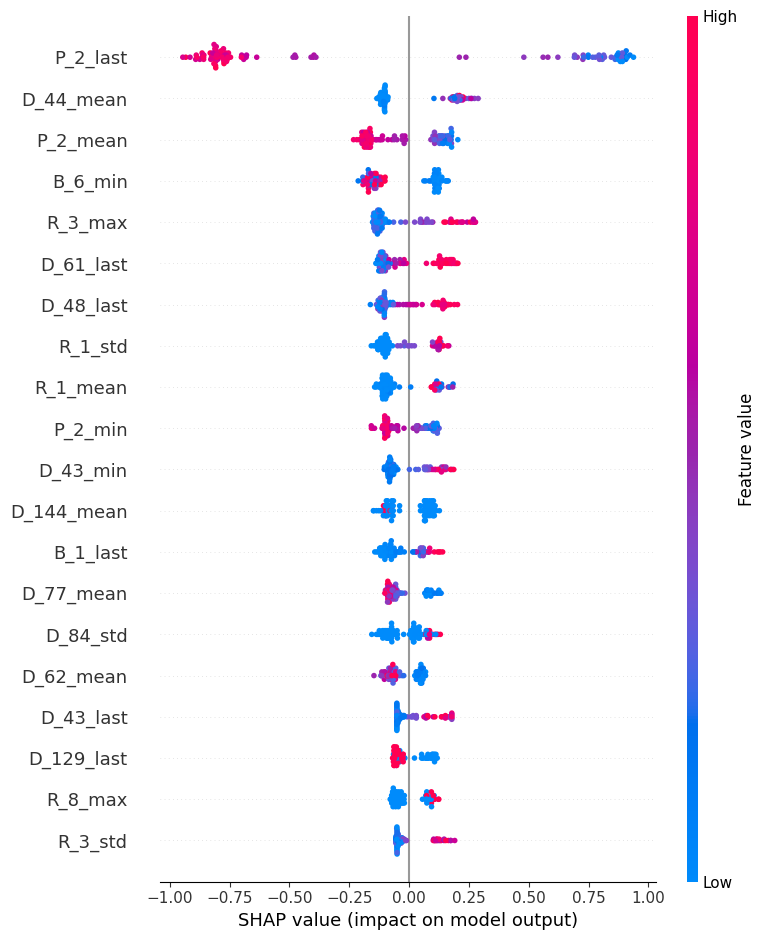

In [549]:
shap.summary_plot(
    shap_values,
    X_test_final.iloc[:100]
)

Next Step

Pick:

one true positive risky customer
one false positive risky customer

from earlier.

In [557]:
X_test_final.iloc[:100]

,P_2_mean,P_2_std,P_2_min,P_2_max,P_2_last,D_39_mean,D_39_std,D_39_min,D_39_max,D_39_last,...,D_63_last_CL,D_63_last_CO,D_63_last_CR,D_63_last_XL,D_63_last_XM,D_63_last_XZ,D_64_last_-1,D_64_last_O,D_64_last_R,D_64_last_U
688,0.315736,0.043630,0.273595,0.395939,0.332669,0.075484,0.114585,0.001415,0.326869,0.005600,...,False,True,False,0,0,0,False,False,False,True
756,0.862655,0.025932,0.810184,0.886281,0.878278,0.005546,0.003085,0.000812,0.009948,0.009653,...,False,True,False,0,0,0,False,False,False,True
4,0.891679,0.042325,0.805045,0.940382,0.871900,0.004644,0.002882,0.000030,0.008680,0.005573,...,False,True,False,0,0,0,False,True,False,False
368,0.491626,0.096173,0.375171,0.652546,0.386691,0.189052,0.183474,0.000773,0.448370,0.210784,...,False,True,False,0,0,0,False,False,False,True
261,0.698956,0.024961,0.646569,0.741579,0.691053,0.258931,0.258937,0.000499,0.682349,0.005906,...,False,False,True,0,0,0,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,0.416462,0.062693,0.316282,0.545946,0.402128,0.284455,0.279121,0.002161,0.685287,0.325357,...,False,True,False,0,0,0,False,False,True,False
85,0.834742,0.044746,0.790962,0.942415,0.826025,0.197435,0.251198,0.001556,0.738628,0.237166,...,False,True,False,0,0,0,False,True,False,False
317,0.891923,0.046364,0.825796,0.966752,0.825796,0.097109,0.146640,0.000084,0.417739,0.330952,...,False,True,False,0,0,0,False,False,True,False
506,0.862847,0.064109,0.773559,0.958189,0.902748,0.359210,0.231726,0.004584,0.678338,0.326278,...,False,False,True,0,0,0,False,True,False,False


Step 1 — Create Sample Variable

In [558]:
sample_X = X_test_final.iloc[:100]

Step 2 — Recompute SHAP Values

In [559]:
shap_values = explainer.shap_values(sample_X)

Step 3 — Force Plot

In [560]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    sample_X.iloc[0]
)

OPTIONAL Better Visualization

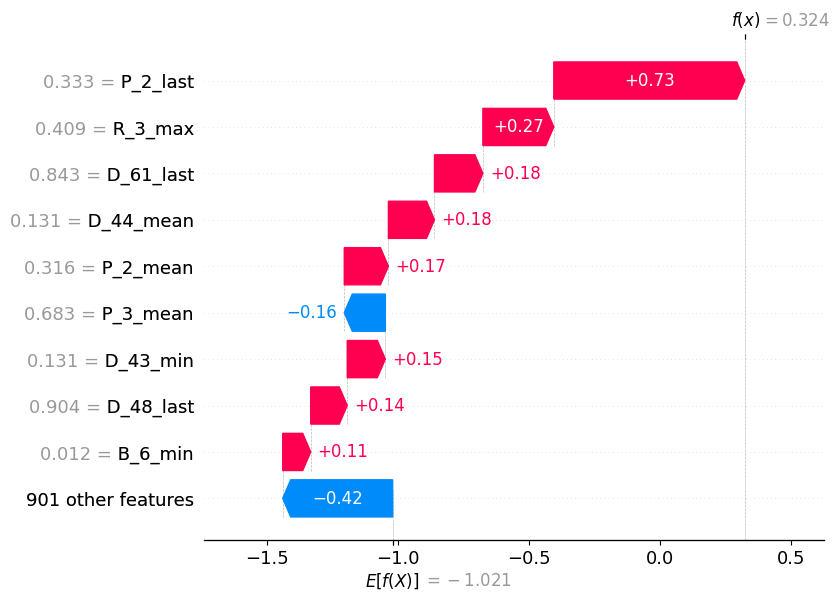

In [561]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=sample_X.iloc[0],
        feature_names=sample_X.columns
    )
)

Step 1 — Sort Data Properly

In [571]:
df_sample = df_sample.sort_values(
    ["customer_ID", "S_2"]
)

Step 2 — Create Recent 3-Month Mean Features

In [572]:
recent_3m = (
    df_sample.groupby("customer_ID")[numerical_features]
    .tail(3)
    .groupby(df_sample.groupby("customer_ID").tail(3)["customer_ID"])
    .mean()
)

Step 3 — Rename Columns

In [573]:
recent_3m.columns = [
    f"{col}_recent3_mean"
    for col in recent_3m.columns
]

recent_3m = recent_3m.reset_index()

Step 4 — Merge Into Main Feature Set

In [574]:
agg_df_full = agg_df_full.merge(
    recent_3m,
    on="customer_ID",
    how="left"
)

Rebuild X and y

In [576]:
X = agg_df_full.drop(columns=["customer_ID", "target"])

y = agg_df_full["target"]

Step 2 — Train-Test Split

In [577]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

Step 3 — Separate Numeric/Categorical

In [578]:
numeric_cols = X_train.select_dtypes(
    include=["number"]
).columns

categorical_cols = X_train.select_dtypes(
    exclude=["number"]
).columns

In [579]:
numeric_cols

Index(['P_2_mean', 'P_2_std', 'P_2_min', 'P_2_max', 'P_2_last', 'D_39_mean',
       'D_39_std', 'D_39_min', 'D_39_max', 'D_39_last',
       ...
       'D_136_recent3_mean', 'D_137_recent3_mean', 'D_138_recent3_mean',
       'D_139_recent3_mean', 'D_140_recent3_mean', 'D_141_recent3_mean',
       'D_142_recent3_mean', 'D_143_recent3_mean', 'D_144_recent3_mean',
       'D_145_recent3_mean'],
      dtype='object', length=1075)

In [580]:
categorical_cols

Index(['D_63_last', 'D_64_last'], dtype='object')

Step 4 — Imputation

In [581]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy="median")

cat_imputer = SimpleImputer(strategy="most_frequent")

Step 5 — Impute Numeric

In [582]:
X_train_num = pd.DataFrame(
    num_imputer.fit_transform(X_train[numeric_cols]),
    columns=numeric_cols,
    index=X_train.index
)

X_test_num = pd.DataFrame(
    num_imputer.transform(X_test[numeric_cols]),
    columns=numeric_cols,
    index=X_test.index
)

Step 6 — Impute Categorical

In [583]:
X_train_cat = pd.DataFrame(
    cat_imputer.fit_transform(X_train[categorical_cols]),
    columns=categorical_cols,
    index=X_train.index
)

X_test_cat = pd.DataFrame(
    cat_imputer.transform(X_test[categorical_cols]),
    columns=categorical_cols,
    index=X_test.index
)

Step 7 — Combine

In [584]:
X_train_imputed = pd.concat(
    [X_train_num, X_train_cat],
    axis=1
)

X_test_imputed = pd.concat(
    [X_test_num, X_test_cat],
    axis=1
)

Step 8 — One-Hot Encoding

In [585]:
X_train_final = pd.get_dummies(X_train_imputed)

X_test_final = pd.get_dummies(X_test_imputed)

Step 9 — Align Columns

In [586]:
X_train_final, X_test_final = X_train_final.align(
    X_test_final,
    join="left",
    axis=1,
    fill_value=0
)

Step 10 — Train Regularized XGBoost

In [587]:
from xgboost import XGBClassifier

xgb_model_recent = XGBClassifier(
    n_estimators=150,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=5,
    reg_alpha=1,
    reg_lambda=5,
    random_state=42,
    eval_metric="logloss"
)

xgb_model_recent.fit(X_train_final, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

Step 11 — Evaluate

In [588]:
xgb_pred_recent = xgb_model_recent.predict(X_test_final)

xgb_prob_recent = xgb_model_recent.predict_proba(
    X_test_final
)[:, 1]

print(
    "Test ROC-AUC:",
    roc_auc_score(y_test, xgb_prob_recent)
)

print(classification_report(
    y_test,
    xgb_pred_recent
))

print(confusion_matrix(
    y_test,
    xgb_pred_recent
))

Test ROC-AUC: 0.9195592286501377
              precision    recall  f1-score   support

           0       0.92      0.93      0.92       121
           1       0.80      0.78      0.79        45

    accuracy                           0.89       166
   macro avg       0.86      0.85      0.85       166
weighted avg       0.88      0.89      0.89       166

[[112   9]
 [ 10  35]]


NEXT MAJOR STEP → Memory Optimization

In [4]:
import pandas as pd

train_data = pd.read_csv(
    "/Users/spurge/Documents/amex-inspired-risk-monitoring/data/raw/amex-default-prediction/train_data.csv"
)

In [13]:
train_data.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5531451 entries, 0 to 5531450
Columns: 190 entries, customer_ID to D_145
dtypes: float32(185), int8(1), object(4)
memory usage: 5.4 GB


In [6]:
def reduce_mem_usage(df):

    for col in df.columns:

        col_type = df[col].dtype

        if col_type != object:

            c_min = df[col].min()
            c_max = df[col].max()

            if str(col_type)[:3] == "int":

                if c_min > -128 and c_max < 127:
                    df[col] = df[col].astype("int8")

                elif c_min > -32768 and c_max < 32767:
                    df[col] = df[col].astype("int16")

                elif c_min > -2147483648 and c_max < 2147483647:
                    df[col] = df[col].astype("int32")

            else:

                df[col] = df[col].astype("float32")

    return df

In [7]:
train_data = reduce_mem_usage(train_data)

In [9]:
train_data.shape

(5531451, 190)

NEXT STEP → Convert To Parquet

In [11]:
train_data.to_parquet(
    "train_data.parquet",
    index=False
)

Then Test Loading Speed

In [12]:
train_data = pd.read_parquet(
    "train_data.parquet"
)

In [14]:
train_data.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5531451 entries, 0 to 5531450
Columns: 190 entries, customer_ID to D_145
dtypes: float32(185), int8(1), object(4)
memory usage: 5.4 GB


NEXT STEP → Convert To Parquet FIRST

In [15]:
train_data.to_parquet(
    "/Users/spurge/Documents/amex-inspired-risk-monitoring/data/raw/amex-default-prediction/train_data.parquet",
    index=False
)

NEXT STEP AFTER PARQUET

In [16]:
all_features = [
    col for col in train_data.columns
    if col not in ["customer_ID", "S_2"]
]

In [22]:
len(all_features)

188

In [23]:
categorical_features = train_data.select_dtypes(
    include=["object"]
).columns.tolist()

print(categorical_features)

['customer_ID', 'S_2', 'D_63', 'D_64']


In [24]:
len(categorical_features)

4

In [27]:
categorical_features = [
    col for col in categorical_features
    if col not in ["customer_ID", "S_2"]
]

print(categorical_features)

['D_63', 'D_64']


In [29]:
numerical_features = [
    col for col in train_data.columns
    if col not in [
        "customer_ID",
        "S_2",
        "D_63",
        "D_64"
    ]
]

In [33]:
len(numerical_features)

186

Step 3 — Numerical Aggregation

In [30]:
num_agg = ["mean", "std", "min", "max", "last"]

num_agg_df = (
    train_data
    .groupby("customer_ID")[numerical_features]
    .agg(num_agg)
)

Step 4 — Flatten Columns

In [31]:
num_agg_df.columns = [
    f"{col}_{agg}"
    for col, agg in num_agg_df.columns
]

num_agg_df = num_agg_df.reset_index()

In [32]:
print(num_agg_df.shape)

(458913, 931)


In [34]:
num_agg_df

,customer_ID,P_2_mean,P_2_std,P_2_min,P_2_max,P_2_last,D_39_mean,D_39_std,D_39_min,D_39_max,...,D_144_mean,D_144_std,D_144_min,D_144_max,D_144_last,D_145_mean,D_145_std,D_145_min,D_145_max,D_145_last
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,0.933824,0.024194,0.868580,0.960384,0.934745,0.010704,0.024444,0.001082,0.091505,...,0.005283,0.002598,0.000610,0.009616,0.002970,0.005814,0.003294,0.000995,0.009827,0.008533
1,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,0.899820,0.022119,0.861109,0.929122,0.880519,0.215205,0.199150,0.002224,0.567403,...,0.004218,0.002871,0.000027,0.009568,0.003169,0.004902,0.002729,0.000796,0.009390,0.008514
2,00001b22f846c82c51f6e3958ccd81970162bae8b007e8...,0.878454,0.028911,0.797670,0.904482,0.880875,0.004181,0.002758,0.000802,0.009704,...,0.005113,0.003638,0.000129,0.009415,0.000834,0.004500,0.002152,0.000443,0.006932,0.003444
3,000041bdba6ecadd89a52d11886e8eaaec9325906c9723...,0.598969,0.020107,0.567442,0.623392,0.621776,0.048862,0.088466,0.000660,0.268476,...,0.004768,0.002654,0.000492,0.009919,0.005560,0.005236,0.003406,0.000029,0.009836,0.002983
4,00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8a...,0.891679,0.042325,0.805045,0.940382,0.871900,0.004644,0.002882,0.000030,0.008680,...,0.004380,0.002633,0.000633,0.009436,0.006944,0.004219,0.003426,0.000083,0.009666,0.000905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
458908,ffff41c8a52833b56430603969b9ca48d208e7c192c6a4...,0.848750,0.041969,0.730505,0.895553,0.844229,0.119236,0.195278,0.002237,0.589866,...,0.005605,0.003264,0.000440,0.009355,0.003009,0.005315,0.002673,0.000145,0.009865,0.004843
458909,ffff518bb2075e4816ee3fe9f3b152c57fc0e6f01bf7fd...,0.859327,0.012425,0.831279,0.868121,0.831279,0.066421,0.123937,0.007327,0.478106,...,0.006052,0.002825,0.001254,0.009966,0.009230,0.005622,0.001671,0.002929,0.007776,0.006435
458910,ffff9984b999fccb2b6127635ed0736dda94e544e67e02...,0.786838,0.014312,0.756983,0.802953,0.800522,0.221548,0.182743,0.000223,0.536278,...,0.004860,0.002944,0.000340,0.009002,0.000340,0.003917,0.002744,0.000204,0.008535,0.002148
458911,ffffa5c46bc8de74f5a4554e74e239c8dee6b9baf38814...,0.804454,0.037442,0.754129,0.856981,0.754129,0.030878,0.081779,0.001332,0.300991,...,0.005287,0.002728,0.001186,0.009836,0.002502,0.186632,0.003162,0.182622,0.191400,0.185527


Step 1 — Aggregate Categoricals

In [42]:
cat_agg = ["last", "nunique"]

cat_agg_df = (
    train_data
    .groupby("customer_ID")[["D_63", "D_64"]]
    .agg(cat_agg)
)

In [43]:
cat_agg_df

D_63         D_64        
                                                   last nunique last nunique
customer_ID                                                                 
0000099d6bd597052cdcda90ffabf56573fe9d7c79be5fb...   CR       1    O       1
00000fd6641609c6ece5454664794f0340ad84dddce9a26...   CO       1    O       1
00001b22f846c82c51f6e3958ccd81970162bae8b007e80...   CO       1    R       1
000041bdba6ecadd89a52d11886e8eaaec9325906c97233...   CO       1    O       1
00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8ad...   CO       1    O       1
...                                                 ...     ...  ...     ...
ffff41c8a52833b56430603969b9ca48d208e7c192c6a40...   CO       1    U       1
ffff518bb2075e4816ee3fe9f3b152c57fc0e6f01bf7fdd...   CO       1    R       1
ffff9984b999fccb2b6127635ed0736dda94e544e67e026...   CO       1    U       1
ffffa5c46bc8de74f5a4554e74e239c8dee6b9baf388145...   CO       1    U       2
fffff1d38b785cef84adeace64f8f83db3a0c31e8d92eab...   CL       1    O       2

[458913 rows x 4 columns]

Step 2 — Flatten Column Names

In [44]:
cat_agg_df.columns = [
    f"{col}_{agg}"
    for col, agg in cat_agg_df.columns
]

cat_agg_df = cat_agg_df.reset_index()

In [45]:
cat_agg_df

,customer_ID,D_63_last,D_63_nunique,D_64_last,D_64_nunique
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,CR,1,O,1
1,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,CO,1,O,1
2,00001b22f846c82c51f6e3958ccd81970162bae8b007e8...,CO,1,R,1
3,000041bdba6ecadd89a52d11886e8eaaec9325906c9723...,CO,1,O,1
4,00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8a...,CO,1,O,1
...,...,...,...,...,...
458908,ffff41c8a52833b56430603969b9ca48d208e7c192c6a4...,CO,1,U,1
458909,ffff518bb2075e4816ee3fe9f3b152c57fc0e6f01bf7fd...,CO,1,R,1
458910,ffff9984b999fccb2b6127635ed0736dda94e544e67e02...,CO,1,U,1
458911,ffffa5c46bc8de74f5a4554e74e239c8dee6b9baf38814...,CO,1,U,2


Step 3 — Check Shape

In [47]:
print(cat_agg_df.shape)

(458913, 5)


Step 4 — Merge Numerical + Categorical

In [48]:
agg_df_full = num_agg_df.merge(
    cat_agg_df,
    on="customer_ID",
    how="left"
)

In [49]:
agg_df_full.shape

(458913, 935)

Step 5 — Add History Length

In [50]:
history_length = (
    train_data
    .groupby("customer_ID")
    .size()
    .reset_index(name="history_length")
)

In [51]:
agg_df_full = agg_df_full.merge(
    history_length,
    on="customer_ID",
    how="left"
)

Step 6 — Load Labels

In [52]:
df_labels = pd.read_csv(
    "/Users/spurge/Documents/amex-inspired-risk-monitoring/data/raw/amex-default-prediction/train_labels.csv"
)

In [53]:
df_labels.shape

(458913, 2)

Step 7 — Merge Target

In [54]:
agg_df_full = agg_df_full.merge(
    df_labels,
    on="customer_ID",
    how="left"
)

Step 8 — Final Validation

In [55]:
print(agg_df_full.shape)

print(
    agg_df_full["target"].isna().sum()
)

(458913, 937)
0


Now we will build model 
Step 1 — Build X and y

In [56]:
X = agg_df_full.drop(
    columns=["customer_ID", "target"]
)

y = agg_df_full["target"]

Step 2 — Train-Test Split

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

Step 3 — Detect Numeric/Categorical

In [58]:
numeric_cols = X_train.select_dtypes(
    include=["number"]
).columns

categorical_cols = X_train.select_dtypes(
    exclude=["number"]
).columns

print("Numeric:", len(numeric_cols))
print("Categorical:", len(categorical_cols))

Numeric: 933
Categorical: 2


Step 4 — Imputation

In [59]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy="median")

cat_imputer = SimpleImputer(strategy="most_frequent")

Step 5 — Numeric Imputation

In [60]:
X_train_num = pd.DataFrame(
    num_imputer.fit_transform(X_train[numeric_cols]),
    columns=numeric_cols,
    index=X_train.index
)

X_test_num = pd.DataFrame(
    num_imputer.transform(X_test[numeric_cols]),
    columns=numeric_cols,
    index=X_test.index
)

Step 6 — Categorical Imputation

In [61]:
X_train_cat = pd.DataFrame(
    cat_imputer.fit_transform(X_train[categorical_cols]),
    columns=categorical_cols,
    index=X_train.index
)

X_test_cat = pd.DataFrame(
    cat_imputer.transform(X_test[categorical_cols]),
    columns=categorical_cols,
    index=X_test.index
)

Step 7 — Combine

In [62]:
X_train_imputed = pd.concat(
    [X_train_num, X_train_cat],
    axis=1
)

X_test_imputed = pd.concat(
    [X_test_num, X_test_cat],
    axis=1
)

Step 8 — One-Hot Encode

In [63]:
X_train_final = pd.get_dummies(
    X_train_imputed
)

X_test_final = pd.get_dummies(
    X_test_imputed
)

Step 9 — Align Columns

In [64]:
X_train_final, X_test_final = X_train_final.align(
    X_test_final,
    join="left",
    axis=1,
    fill_value=0
)

Step 10 — Train Large-Scale XGBoost

In [65]:
from xgboost import XGBClassifier

xgb_large = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=10,
    reg_alpha=2,
    reg_lambda=10,
    random_state=42,
    eval_metric="logloss",
    tree_method="hist"
)

Train

In [66]:
xgb_large.fit(
    X_train_final,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=10, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

NEXT STEP → Predictions

In [67]:
xgb_pred = xgb_large.predict(
    X_test_final
)

xgb_prob = xgb_large.predict_proba(
    X_test_final
)[:, 1]

Step 2 — Evaluate

In [68]:
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print(
    "Test ROC-AUC:",
    roc_auc_score(y_test, xgb_prob)
)

print(
    classification_report(
        y_test,
        xgb_pred
    )
)

print(
    confusion_matrix(
        y_test,
        xgb_pred
    )
)

Test ROC-AUC: 0.960523837339421
              precision    recall  f1-score   support

           0       0.93      0.93      0.93     68017
           1       0.81      0.81      0.81     23766

    accuracy                           0.90     91783
   macro avg       0.87      0.87      0.87     91783
weighted avg       0.90      0.90      0.90     91783

[[63554  4463]
 [ 4558 19208]]


In [69]:
X_train_final

,P_2_mean,P_2_std,P_2_min,P_2_max,P_2_last,D_39_mean,D_39_std,D_39_min,D_39_max,D_39_last,...,D_63_last_CL,D_63_last_CO,D_63_last_CR,D_63_last_XL,D_63_last_XM,D_63_last_XZ,D_64_last_-1,D_64_last_O,D_64_last_R,D_64_last_U
36033,0.126857,0.094224,-0.078048,0.213901,-0.078048,0.504709,0.796118,0.002831,2.388655,0.003660,...,False,True,False,False,False,False,False,False,True,False
65831,0.581100,0.039420,0.531114,0.637622,0.600520,0.240982,0.184901,0.009770,0.709922,0.709922,...,False,True,False,False,False,False,False,False,False,True
408773,0.462874,0.202419,0.149882,0.763002,0.249789,0.188839,0.260714,0.004201,0.740344,0.097226,...,False,True,False,False,False,False,False,True,False,False
235833,0.659785,0.071487,0.510063,0.708656,0.702627,0.016473,0.040385,0.000119,0.150511,0.007076,...,False,True,False,False,False,False,False,True,False,False
270809,0.898495,0.028895,0.846045,0.941035,0.913598,0.004578,0.002419,0.000428,0.008236,0.001891,...,False,True,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438531,0.077161,0.070761,-0.046301,0.149141,0.046361,0.422608,0.510555,0.000797,1.471157,0.006180,...,False,True,False,False,False,False,False,True,False,False
447964,0.740333,0.010113,0.713737,0.752572,0.743998,0.211926,0.218906,0.001451,0.539203,0.008362,...,False,False,True,False,False,False,False,False,False,True
125197,0.758221,0.029355,0.699566,0.783937,0.707106,0.003472,0.002688,0.000202,0.007461,0.000202,...,False,True,False,False,False,False,False,False,True,False
328502,0.399903,0.061870,0.313722,0.525141,0.313722,0.346102,0.420803,0.002692,0.943851,0.030626,...,False,True,False,False,False,False,False,False,True,False


In [70]:
X_test_final

,P_2_mean,P_2_std,P_2_min,P_2_max,P_2_last,D_39_mean,D_39_std,D_39_min,D_39_max,D_39_last,...,D_63_last_CL,D_63_last_CO,D_63_last_CR,D_63_last_XL,D_63_last_XM,D_63_last_XZ,D_64_last_-1,D_64_last_O,D_64_last_R,D_64_last_U
457900,0.226047,0.191234,-0.078775,0.478678,0.315913,0.450956,0.856193,0.000103,2.682907,0.009365,...,False,False,True,False,False,False,False,True,False,False
36384,0.670445,0.060178,0.591011,0.771977,0.771977,0.188168,0.270666,0.000619,0.735717,0.117988,...,False,True,False,False,False,False,False,True,False,False
198592,0.978939,0.014110,0.950828,0.996102,0.980736,0.004894,0.002554,0.000039,0.008538,0.008129,...,False,True,False,False,False,False,False,False,False,True
45498,1.005204,0.003196,0.997083,1.009193,1.007325,0.058167,0.077151,0.000026,0.207811,0.003281,...,False,True,False,False,False,False,False,True,False,False
232941,0.695527,0.129984,0.459667,0.940571,0.631007,0.071635,0.147596,0.000027,0.473774,0.295834,...,False,True,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40032,0.766355,0.041430,0.676665,0.849333,0.819130,0.004852,0.002832,0.001044,0.009952,0.001044,...,False,True,False,False,False,False,False,True,False,False
138836,0.920900,0.009457,0.907642,0.933788,0.915171,0.113522,0.163078,0.000065,0.506792,0.298202,...,False,True,False,False,False,False,False,False,True,False
106193,0.727043,0.023354,0.669430,0.751871,0.743939,0.121488,0.151500,0.001318,0.389308,0.002012,...,False,True,False,False,False,False,False,False,True,False
110215,0.758169,0.064229,0.622800,0.813930,0.776226,0.046436,0.107952,0.000180,0.329192,0.064113,...,False,True,False,False,False,False,False,True,False,False


In [71]:
train_prob = xgb_large.predict_proba(
    X_train_final
)[:, 1]

print(
    "Train ROC-AUC:",
    roc_auc_score(
        y_train,
        train_prob
    )
)

Train ROC-AUC: 0.9617750223504336


NEXT STEP (Fast)


portfolio risk bands

In [72]:
risk_df = pd.DataFrame({
    "actual_target": y_test,
    "predicted_probability": xgb_prob
})

Create Rsik Bands

In [73]:
risk_df["risk_band"] = pd.cut(
    risk_df["predicted_probability"],
    bins=[0, 0.2, 0.5, 0.8, 1.0],
    labels=["Low", "Medium", "High", "Critical"]
)

Then Analyze Portfolio Distribution

In [74]:
print(
    risk_df["risk_band"].value_counts()
)

risk_band
Low         58778
Critical    13051
High        10620
Medium       9334
Name: count, dtype: int64


Then Default Rate By Risk Band

In [75]:
print(
    risk_df.groupby("risk_band")[
        "actual_target"
    ].mean()
)

risk_band
Low         0.023546
Medium      0.340047
High        0.667702
Critical    0.928435
Name: actual_target, dtype: float64


/var/folders/_x/zslfq00j131045lvgjlh0m540000gn/T/ipykernel_37214/2356998993.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_df.groupby("risk_band")[


probability calibration

trustworthy probability estimation system

Step 1:Import 

In [76]:
from sklearn.calibration import CalibratedClassifierCV

Step 2 — Create Calibrated Model

In [77]:
calibrated_model = CalibratedClassifierCV(
    xgb_large,
    method="isotonic",
    cv=3
)

Step 3 — Fit Calibration

In [78]:
calibrated_model.fit(
    X_train_final,
    y_train
)

CalibratedClassifierCV(cv=3,
                       estimator=XGBClassifier(base_score=None, booster=None,
                                               callbacks=None,
                                               colsample_bylevel=None,
                                               colsample_bynode=None,
                                               colsample_bytree=0.7,
                                               device=None,
                                               early_stopping_rounds=None,
                                               enable_categorical=False,
                                               eval_metric='logloss',
                                               feature_types=None, gamma=None,
                                               grow_policy=None,
                                               importance_type=None,
                                               interaction_constraints=None,
                                               learning_rate=0.05, max_bin=None,
                                               max_cat_threshold=None,
                                               max_cat_to_onehot=None,
                                               max_delta_step=None, max_depth=4,
                                               max_leaves=None,
                                               min_child_weight=10, missing=nan,
                                               monotone_constraints=None,
                                               multi_strategy=None,
                                               n_estimators=300, n_jobs=None,
                                               num_parallel_tree=None,
                                               random_state=42, ...),
                       method='isotonic')

Step 4 — Predict Calibrated Probabilities

In [79]:
calibrated_prob = calibrated_model.predict_proba(
    X_test_final
)[:, 1]

Step 5 — Compare ROC-AUC

In [80]:
print(
    "Original ROC-AUC:",
    roc_auc_score(y_test, xgb_prob)
)

print(
    "Calibrated ROC-AUC:",
    roc_auc_score(y_test, calibrated_prob)
)

Original ROC-AUC: 0.960523837339421
Calibrated ROC-AUC: 0.9606339659373833


NEXT STEP → Calibration Curve

In [81]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

Step 2 — Compute Calibration Data

In [82]:
prob_true, prob_pred = calibration_curve(
    y_test,
    calibrated_prob,
    n_bins=10
)

Step 3 — Plot

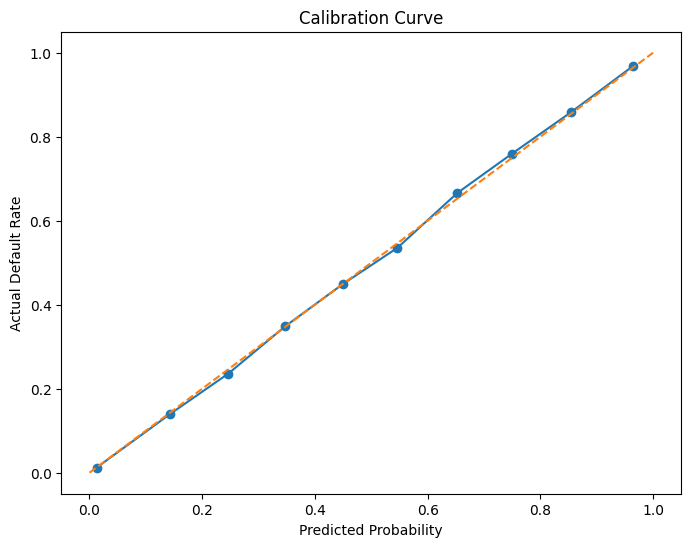

In [83]:
plt.figure(figsize=(8,6))

plt.plot(
    prob_pred,
    prob_true,
    marker='o'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("Predicted Probability")

plt.ylabel("Actual Default Rate")

plt.title("Calibration Curve")

plt.show()

FIRST SIMPLE VERSION

We’ll simulate:

portfolio migration across risk bands.

This becomes VERY intuitive 


Step 1 — Create Risk Distribution

In [84]:
risk_distribution = (
    risk_df["risk_band"]
    .value_counts(normalize=True)
    .sort_index()
)

print(risk_distribution)

risk_band
Low         0.640402
Medium      0.101696
High        0.115708
Critical    0.142194
Name: proportion, dtype: float64


Step 2 — Plot Portfolio Composition

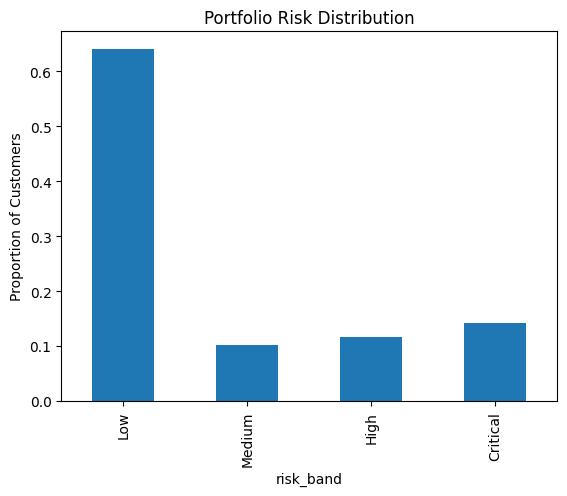

In [85]:
import matplotlib.pyplot as plt

risk_distribution.plot(
    kind="bar"
)

plt.title("Portfolio Risk Distribution")

plt.ylabel("Proportion of Customers")

plt.show()

Simple Stress Simulation

We artificially increase probabilities slightly.

In [86]:
risk_df["stressed_probability"] = (
    risk_df["predicted_probability"] * 1.15
).clip(0, 1)

Recreate Risk Bands

In [87]:
risk_df["stressed_risk_band"] = pd.cut(
    risk_df["stressed_probability"],
    bins=[0, 0.2, 0.5, 0.8, 1.0],
    labels=["Low", "Medium", "High", "Critical"]
)

Compare Before vs After

In [88]:
print("Original Distribution:\n")

print(
    risk_df["risk_band"]
    .value_counts(normalize=True)
)

print("\nStressed Distribution:\n")

print(
    risk_df["stressed_risk_band"]
    .value_counts(normalize=True)
)

Original Distribution:

risk_band
Low         0.640402
Critical    0.142194
High        0.115708
Medium      0.101696
Name: proportion, dtype: float64

Stressed Distribution:

stressed_risk_band
Low         0.629365
Critical    0.188063
High        0.092218
Medium      0.090354
Name: proportion, dtype: float64


NEXT STEP → Migration Matrix

In [89]:
migration_matrix = pd.crosstab(
    risk_df["risk_band"],
    risk_df["stressed_risk_band"]
)

print(migration_matrix)

stressed_risk_band    Low  Medium  High  Critical
risk_band                                        
Low                 57765    1013     0         0
Medium                  0    7280  2054         0
High                    0       0  6410      4210
Critical                0       0     0     13051


EVEN Better → Row Normalized

In [90]:
migration_matrix_pct = pd.crosstab(
    risk_df["risk_band"],
    risk_df["stressed_risk_band"],
    normalize="index"
)

print(migration_matrix_pct)

stressed_risk_band       Low    Medium      High  Critical
risk_band                                                 
Low                 0.982766  0.017234  0.000000  0.000000
Medium              0.000000  0.779944  0.220056  0.000000
High                0.000000  0.000000  0.603578  0.396422
Critical            0.000000  0.000000  0.000000  1.000000


Step 1 — Import SHAP

In [91]:
import shap

Step 2 — Create Explainer

In [107]:
explainer = shap.TreeExplainer(
    xgb_large
)

Step 3 — Sample Customers

In [125]:
sample_X = X_test_final.sample(
    50000,
    random_state=42
)

In [126]:
sample_X.shape

(50000, 943)

Step 4 — Compute SHAP Values

In [127]:
shap_values = explainer.shap_values(
    sample_X
)

Step 5 — Global SHAP Summary Plot

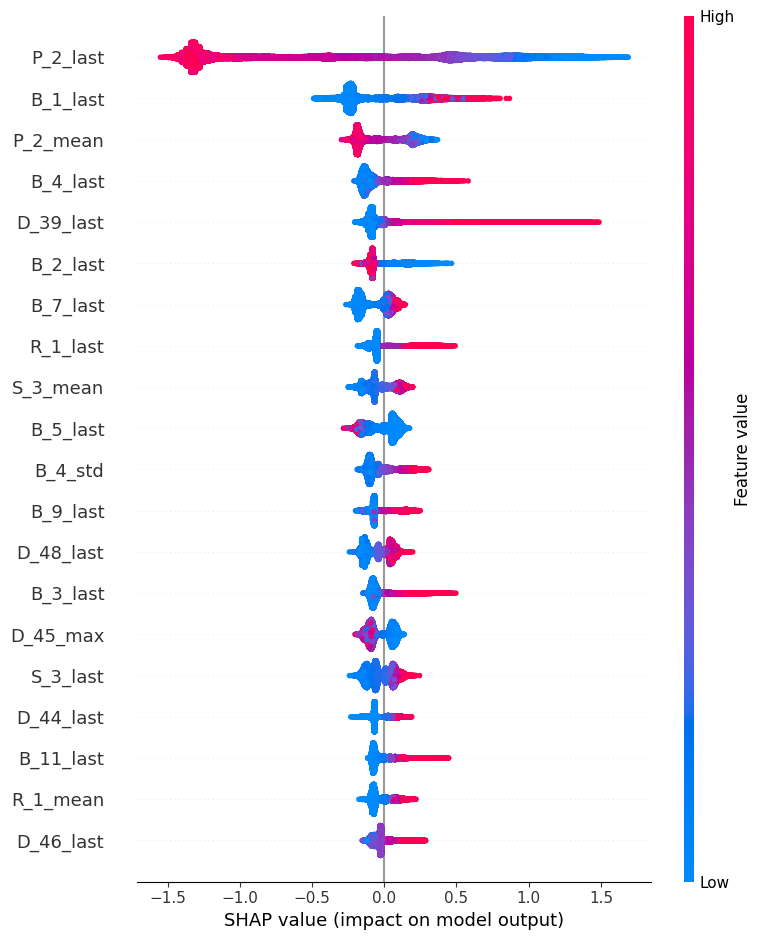

In [128]:
shap.summary_plot(
    shap_values,
    sample_X
)

Step 1 — Create Top Feature List

In [136]:
top_features = [
    "P_2_last",
    "B_1_last",
    "P_2_mean",
    "B_4_last",
    "D_39_last",
    "B_2_last",
    "B_7_last",
    "R_1_last",
    "S_3_mean",
    "B_5_last"
]

Step 2 — Create Clustering Dataset

In [137]:
cluster_df = X_test_final[
    top_features
].copy()

In [138]:
cluster_df

,P_2_last,B_1_last,P_2_mean,B_4_last,D_39_last,B_2_last,B_7_last,R_1_last,S_3_mean,B_5_last
457900,0.315913,-0.006032,0.226047,0.057920,0.009365,0.811237,0.272303,0.009453,0.199741,0.023948
36384,0.771977,0.009775,0.670445,0.385224,0.117988,1.000583,0.143273,0.000920,0.112201,0.030968
198592,0.980736,0.002793,0.978939,0.018033,0.008129,0.819025,0.032434,0.001626,0.173906,0.004371
45498,1.007325,0.017714,1.005204,0.042070,0.003281,1.007170,0.035208,0.003768,0.121050,0.020070
232941,0.631007,0.564358,0.695527,0.089810,0.295834,0.058714,0.169086,0.002128,0.126826,0.041075
...,...,...,...,...,...,...,...,...,...,...
40032,0.819130,0.007134,0.766355,0.145744,0.001044,0.813214,0.068860,0.000292,0.173906,0.008299
138836,0.915171,0.141408,0.920900,0.044405,0.298202,1.008754,0.041653,0.009494,0.215898,0.034601
106193,0.743939,0.011216,0.727043,0.027839,0.002012,1.009000,0.029609,0.000172,0.088004,0.027584
110215,0.776226,0.010447,0.758169,0.015872,0.064113,0.812237,0.011989,0.006636,0.198731,0.006901


Step 3 — Standardize

VERY important for clustering.

In [139]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(
    cluster_df
)

In [140]:
cluster_scaled

array([[-1.19928627, -0.6280636 , -1.79144826, ..., -0.3502039 ,
        -0.14897855, -0.14966517],
       [ 0.51244562, -0.55958196,  0.09534393, ..., -0.38089682,
        -0.69306542, -0.12990534],
       [ 1.29597566, -0.58982883,  1.40512484, ..., -0.37835569,
        -0.30955105, -0.20477181],
       ...,
       [ 0.4072086 , -0.5533377 ,  0.33564615, ..., -0.38358646,
        -0.84346103, -0.13943163],
       [ 0.52839185, -0.55667104,  0.46779595, ..., -0.36033552,
        -0.15525252, -0.1976509 ],
       [-0.66309384,  2.74889488, -0.78047155, ..., -0.36531673,
         1.07374721, -0.19137044]])

Step 4 — Run KMeans

In [141]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

clusters = kmeans.fit_predict(
    cluster_scaled
)

In [144]:
kmeans

KMeans(n_clusters=4, random_state=42)

In [145]:
clusters

array([2, 0, 0, ..., 0, 0, 2], dtype=int32)

Step 5 — Attach Cluster Labels

In [146]:
cluster_df["cluster"] = clusters

cluster_df["default"] = y_test.values

cluster_df["predicted_pd"] = calibrated_prob

In [147]:
cluster_df

,P_2_last,B_1_last,P_2_mean,B_4_last,D_39_last,B_2_last,B_7_last,R_1_last,S_3_mean,B_5_last,cluster,default,predicted_pd
457900,0.315913,-0.006032,0.226047,0.057920,0.009365,0.811237,0.272303,0.009453,0.199741,0.023948,2,1,0.239782
36384,0.771977,0.009775,0.670445,0.385224,0.117988,1.000583,0.143273,0.000920,0.112201,0.030968,0,0,0.013825
198592,0.980736,0.002793,0.978939,0.018033,0.008129,0.819025,0.032434,0.001626,0.173906,0.004371,0,0,0.000540
45498,1.007325,0.017714,1.005204,0.042070,0.003281,1.007170,0.035208,0.003768,0.121050,0.020070,0,0,0.000548
232941,0.631007,0.564358,0.695527,0.089810,0.295834,0.058714,0.169086,0.002128,0.126826,0.041075,2,1,0.121360
...,...,...,...,...,...,...,...,...,...,...,...,...,...
40032,0.819130,0.007134,0.766355,0.145744,0.001044,0.813214,0.068860,0.000292,0.173906,0.008299,0,0,0.001756
138836,0.915171,0.141408,0.920900,0.044405,0.298202,1.008754,0.041653,0.009494,0.215898,0.034601,0,0,0.001869
106193,0.743939,0.011216,0.727043,0.027839,0.002012,1.009000,0.029609,0.000172,0.088004,0.027584,0,0,0.001331
110215,0.776226,0.010447,0.758169,0.015872,0.064113,0.812237,0.011989,0.006636,0.198731,0.006901,0,0,0.011877


Step 6 — Analyze Clusters

MOST important part.

In [148]:
cluster_summary = cluster_df.groupby(
    "cluster"
).agg({
    "predicted_pd": "mean",
    "default": "mean"
})

print(cluster_summary)

         predicted_pd   default
cluster                        
0            0.035005  0.036169
1            0.947540  0.947771
2            0.544358  0.542861
3            0.038672  0.074074
